In [181]:
# HOUSE PRICE PREDICTION CAPESTONE PROJECT

In [1]:
# ============================================================
# 0. IMPORTS & SETUP
# ============================================================

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


from scipy import stats
from scipy.stats import skew, kurtosis, norm


from sklearn.model_selection import train_test_split, cross_val_score,KFold
from sklearn.preprocessing import LabelEncoder, StandardScaler, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression,Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


sns.set_style('whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

SEED = 42
np.random.seed(SEED)
print('All libraries loaded succesfully')
      

All libraries loaded succesfully


In [3]:
# TASK 1 : Complete Data Analysis Report

In [4]:
# ============================================================
# 1.1 LOAD DATA
# ============================================================

In [5]:
df = pd.read_csv("data.csv.xls")
df

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


In [6]:
print(f'Dataset Shape: {df.shape}')

Dataset Shape: (1460, 81)


In [7]:
print(f'Rows: {df.shape[0]:,}  |  Columns : {df.shape[1]}')


Rows: 1,460  |  Columns : 81


In [8]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [9]:
df.tail()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125
1459,1460,20,RL,75.0,9937,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2008,WD,Normal,147500


In [10]:
# ============================================================
# 1.2 BASIC INFO
# ============================================================

In [11]:
print('== Data Types ===')
print(df.dtypes.value_counts())

== Data Types ===
object     43
int64      35
float64     3
Name: count, dtype: int64


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [13]:
# ============================================================
# 1.3 STATISTICAL SUMMARY
# ============================================================

In [14]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [15]:
df.describe().T.style.background_gradient(cmap='Blues')

,count,mean,std,min,25%,50%,75%,max
Id,1460.000000,730.500000,421.610009,1.000000,365.750000,730.500000,1095.250000,1460.000000
MSSubClass,1460.000000,56.897260,42.300571,20.000000,20.000000,50.000000,70.000000,190.000000
LotFrontage,1201.000000,70.049958,24.284752,21.000000,59.000000,69.000000,80.000000,313.000000
LotArea,1460.000000,10516.828082,9981.264932,1300.000000,7553.500000,9478.500000,11601.500000,215245.000000
OverallQual,1460.000000,6.099315,1.382997,1.000000,5.000000,6.000000,7.000000,10.000000
OverallCond,1460.000000,5.575342,1.112799,1.000000,5.000000,5.000000,6.000000,9.000000
YearBuilt,1460.000000,1971.267808,30.202904,1872.000000,1954.000000,1973.000000,2000.000000,2010.000000
YearRemodAdd,1460.000000,1984.865753,20.645407,1950.000000,1967.000000,1994.000000,2004.000000,2010.000000
MasVnrArea,1452.000000,103.685262,181.066207,0.000000,0.000000,0.000000,166.000000,1600.000000
BsmtFinSF1,1460.000000,443.639726,456.098091,0.000000,0.000000,383.500000,712.250000,5644.000000


In [16]:
# ============================================================
# 1.4 MISSING VALUE ANALYSIS
# ============================================================

In [17]:
missing = df.isnull().sum()
missing

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

In [18]:
missing = missing[missing > 0].sort_values(ascending=False)
missing

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtFinType1      37
BsmtCond          37
BsmtQual          37
MasVnrArea         8
Electrical         1
dtype: int64

In [19]:
missing_pct = (missing / len(df) * 100).round(2)
missing_pct

PoolQC          99.52
MiscFeature     96.30
Alley           93.77
Fence           80.75
MasVnrType      59.73
FireplaceQu     47.26
LotFrontage     17.74
GarageType       5.55
GarageYrBlt      5.55
GarageFinish     5.55
GarageQual       5.55
GarageCond       5.55
BsmtFinType2     2.60
BsmtExposure     2.60
BsmtFinType1     2.53
BsmtCond         2.53
BsmtQual         2.53
MasVnrArea       0.55
Electrical       0.07
dtype: float64

In [20]:
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df

,Missing Count,Missing %
PoolQC,1453,99.52
MiscFeature,1406,96.30
Alley,1369,93.77
Fence,1179,80.75
MasVnrType,872,59.73
FireplaceQu,690,47.26
LotFrontage,259,17.74
GarageType,81,5.55
GarageYrBlt,81,5.55
GarageFinish,81,5.55


In [21]:
#Bar Chart

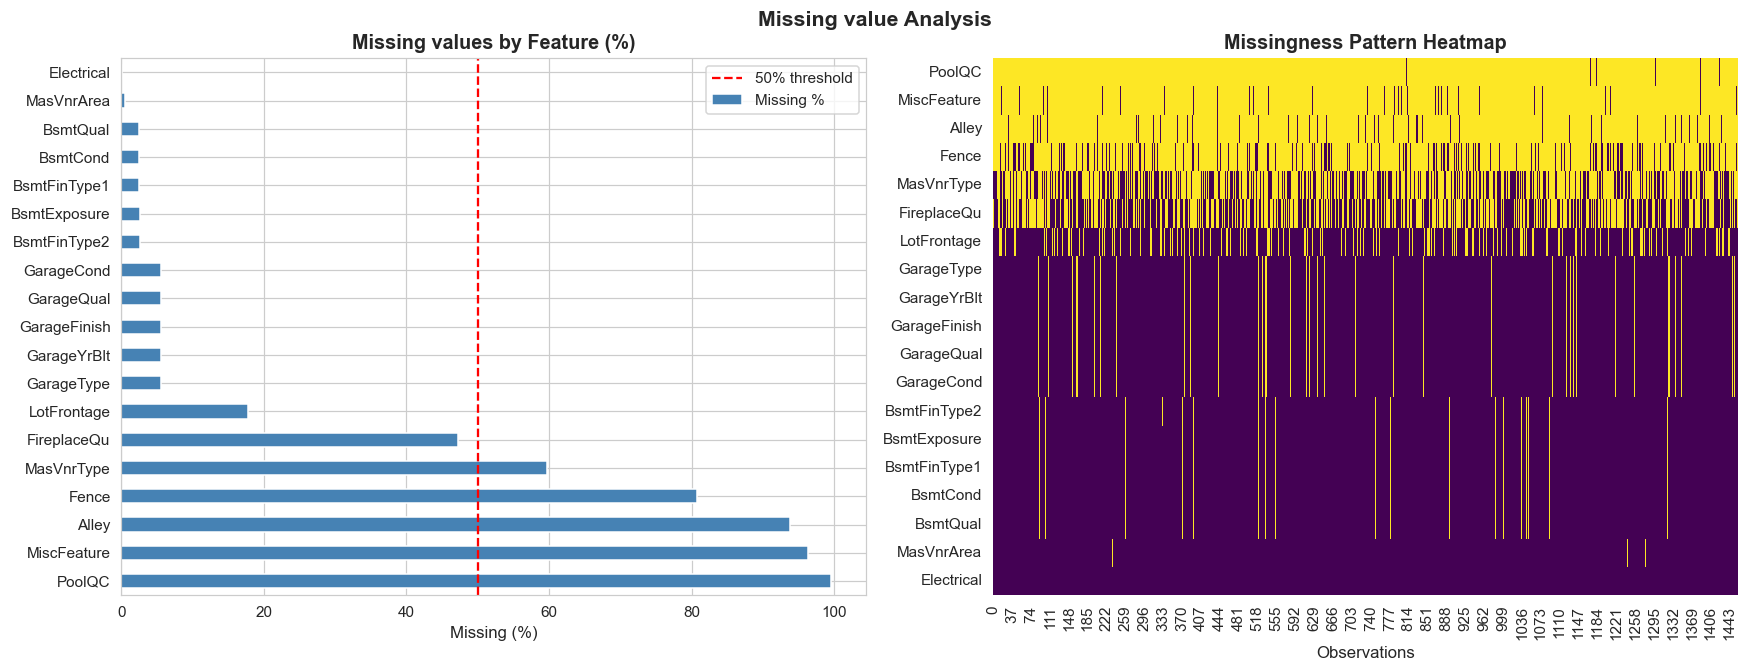

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

missing_df['Missing %'].plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Missing values by Feature (%)', fontweight='bold')
axes[0].set_xlabel('Missing (%)')
axes[0].axvline(50, color='red', linestyle='--', label='50% threshold')
axes[0].legend()


miss_cols = missing_df.index.tolist()
sns.heatmap(df[miss_cols].isnull().T, cbar=False, cmap='viridis', ax=axes[1], yticklabels=True)
axes[1].set_title('Missingness Pattern Heatmap', fontweight='bold')
axes[1].set_xlabel('Observations')

plt.tight_layout()
plt.suptitle('Missing value Analysis', y=1.01, fontsize=14, fontweight='bold')
plt.show()

                  

In [23]:
print(missing_df)

              Missing Count  Missing %
PoolQC                 1453      99.52
MiscFeature            1406      96.30
Alley                  1369      93.77
Fence                  1179      80.75
MasVnrType              872      59.73
FireplaceQu             690      47.26
LotFrontage             259      17.74
GarageType               81       5.55
GarageYrBlt              81       5.55
GarageFinish             81       5.55
GarageQual               81       5.55
GarageCond               81       5.55
BsmtFinType2             38       2.60
BsmtExposure             38       2.60
BsmtFinType1             37       2.53
BsmtCond                 37       2.53
BsmtQual                 37       2.53
MasVnrArea                8       0.55
Electrical                1       0.07


In [24]:
# ============================================================
# 1.5 TARGET VARIABLE ANALYSIS — SalePrice
# ============================================================

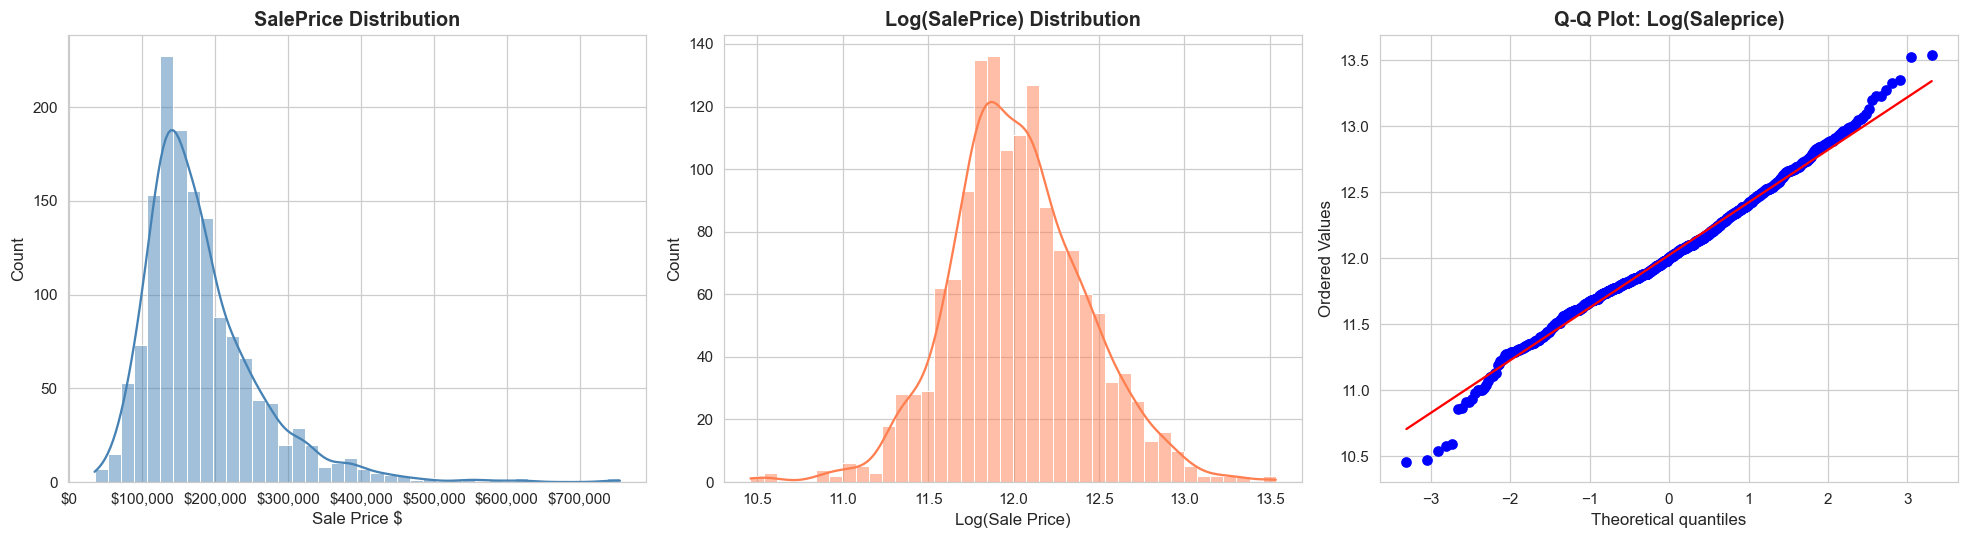

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

sns.histplot(df['SalePrice'],
             kde=True,
             ax=axes[0],
             color='steelblue',
             bins=40)

axes[0].set_title('SalePrice Distribution', fontweight='bold')
axes[0].set_xlabel('Sale Price $')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

log_price = np.log1p(df['SalePrice'])
sns.histplot(log_price, kde=True, ax=axes[1], color='coral', bins=40)
axes[1].set_title('Log(SalePrice) Distribution', fontweight='bold')
axes[1].set_xlabel('Log(Sale Price)')

stats.probplot(log_price, dist='norm', plot=axes[2])
axes[2].set_title('Q-Q Plot: Log(Saleprice)', fontweight='bold')

plt.tight_layout()
plt.show()


In [26]:
print(f'SalePrice Stats:')
print(f'  Mean:       ${df['SalePrice'].mean():,.0f}')
print(f'  Median:     ${df['SalePrice'].median():,.0f}')
print(f'  Std Dev:    ${df['SalePrice'].std():,.0f}')
print(f'  Min:        ${df['SalePrice'].min():,.0f}')
print(f'  Max:        ${df['SalePrice'].max():,.0f}')
print(f'  Skewness:    {skew(df['SalePrice']):.3f}')
print(f'  Kurtosis:    {kurtosis(df['SalePrice']):.3f}')
print(f'  Skewness after log: {skew(log_price):.3f}')

SalePrice Stats:
  Mean:       $180,921
  Median:     $163,000
  Std Dev:    $79,443
  Min:        $34,900
  Max:        $755,000
  Skewness:    1.881
  Kurtosis:    6.510
  Skewness after log: 0.121


In [27]:
# ============================================================
# 1.6 NUMERICAL FEATURES — DISTRIBUTION & SKEWNESS
# ============================================================

In [28]:
num_cols = df.select_dtypes(include=[np.number]).columns.drop(['Id', 'SalePrice']).tolist()
num_cols

['MSSubClass',
 'LotFrontage',
 'LotArea',
 'OverallQual',
 'OverallCond',
 'YearBuilt',
 'YearRemodAdd',
 'MasVnrArea',
 'BsmtFinSF1',
 'BsmtFinSF2',
 'BsmtUnfSF',
 'TotalBsmtSF',
 '1stFlrSF',
 '2ndFlrSF',
 'LowQualFinSF',
 'GrLivArea',
 'BsmtFullBath',
 'BsmtHalfBath',
 'FullBath',
 'HalfBath',
 'BedroomAbvGr',
 'KitchenAbvGr',
 'TotRmsAbvGrd',
 'Fireplaces',
 'GarageYrBlt',
 'GarageCars',
 'GarageArea',
 'WoodDeckSF',
 'OpenPorchSF',
 'EnclosedPorch',
 '3SsnPorch',
 'ScreenPorch',
 'PoolArea',
 'MiscVal',
 'MoSold',
 'YrSold']

In [29]:
skewness = df[num_cols].apply(lambda x: skew(x.dropna())).sort_values(ascending=False)
skewness

MiscVal          24.451640
PoolArea         14.813135
LotArea          12.195142
3SsnPorch        10.293752
LowQualFinSF      9.002080
KitchenAbvGr      4.483784
BsmtFinSF2        4.250888
ScreenPorch       4.117977
BsmtHalfBath      4.099186
EnclosedPorch     3.086696
MasVnrArea        2.666326
OpenPorchSF       2.361912
LotFrontage       2.160866
BsmtFinSF1        1.683771
WoodDeckSF        1.539792
TotalBsmtSF       1.522688
MSSubClass        1.406210
1stFlrSF          1.375342
GrLivArea         1.365156
BsmtUnfSF         0.919323
2ndFlrSF          0.812194
OverallCond       0.692355
TotRmsAbvGrd      0.675646
HalfBath          0.675203
Fireplaces        0.648898
BsmtFullBath      0.595454
OverallQual       0.216721
MoSold            0.211835
BedroomAbvGr      0.211572
GarageArea        0.179796
YrSold            0.096170
FullBath          0.036524
GarageCars       -0.342197
YearRemodAdd     -0.503044
YearBuilt        -0.612831
GarageYrBlt      -0.648708
dtype: float64

In [30]:
high_skew = skewness[abs(skewness) > 0.75]
high_skew

MiscVal          24.451640
PoolArea         14.813135
LotArea          12.195142
3SsnPorch        10.293752
LowQualFinSF      9.002080
KitchenAbvGr      4.483784
BsmtFinSF2        4.250888
ScreenPorch       4.117977
BsmtHalfBath      4.099186
EnclosedPorch     3.086696
MasVnrArea        2.666326
OpenPorchSF       2.361912
LotFrontage       2.160866
BsmtFinSF1        1.683771
WoodDeckSF        1.539792
TotalBsmtSF       1.522688
MSSubClass        1.406210
1stFlrSF          1.375342
GrLivArea         1.365156
BsmtUnfSF         0.919323
2ndFlrSF          0.812194
dtype: float64

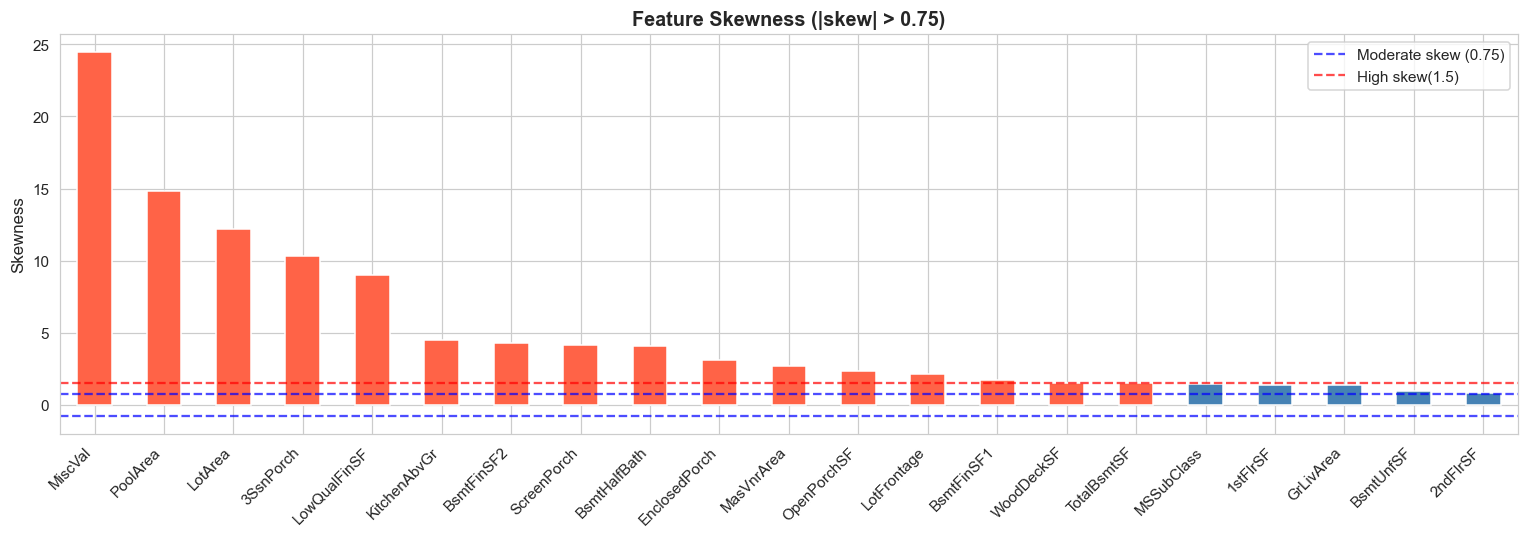

In [31]:
fig,ax =plt.subplots(figsize=(14,5))
colors=['tomato' if abs(v) > 1.5 else 'steelblue' if abs(v) > 0.75 else 'lightgreen' for v in high_skew.values]
high_skew.plot(kind='bar',
               ax=ax,
               color=colors,
               edgecolor='white'
              )

ax.axhline(0.75,
           color='blue',
           linestyle='--',
           alpha=0.7,
           label='Moderate skew (0.75)'
          )

ax.axhline(-0.75,
           color='blue',
           linestyle='--',
           alpha=0.7
          )

ax.axhline(1.5,
           color='red',
           linestyle='--',
           alpha=0.7,
           label='High skew(1.5)'
          )

ax.set_title('Feature Skewness (|skew| > 0.75)', fontweight='bold')
ax.set_ylabel('Skewness')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [32]:
# ============================================================
# 1.7 CATEGORICAL FEATURES — FREQUENCY ANALYSIS
# ============================================================

In [33]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
cat_cols

['MSZoning',
 'Street',
 'Alley',
 'LotShape',
 'LandContour',
 'Utilities',
 'LotConfig',
 'LandSlope',
 'Neighborhood',
 'Condition1',
 'Condition2',
 'BldgType',
 'HouseStyle',
 'RoofStyle',
 'RoofMatl',
 'Exterior1st',
 'Exterior2nd',
 'MasVnrType',
 'ExterQual',
 'ExterCond',
 'Foundation',
 'BsmtQual',
 'BsmtCond',
 'BsmtExposure',
 'BsmtFinType1',
 'BsmtFinType2',
 'Heating',
 'HeatingQC',
 'CentralAir',
 'Electrical',
 'KitchenQual',
 'Functional',
 'FireplaceQu',
 'GarageType',
 'GarageFinish',
 'GarageQual',
 'GarageCond',
 'PavedDrive',
 'PoolQC',
 'Fence',
 'MiscFeature',
 'SaleType',
 'SaleCondition']

In [34]:
print(f' Categorical columns ({len(cat_cols)}): {cat_cols}')

 Categorical columns (43): ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']


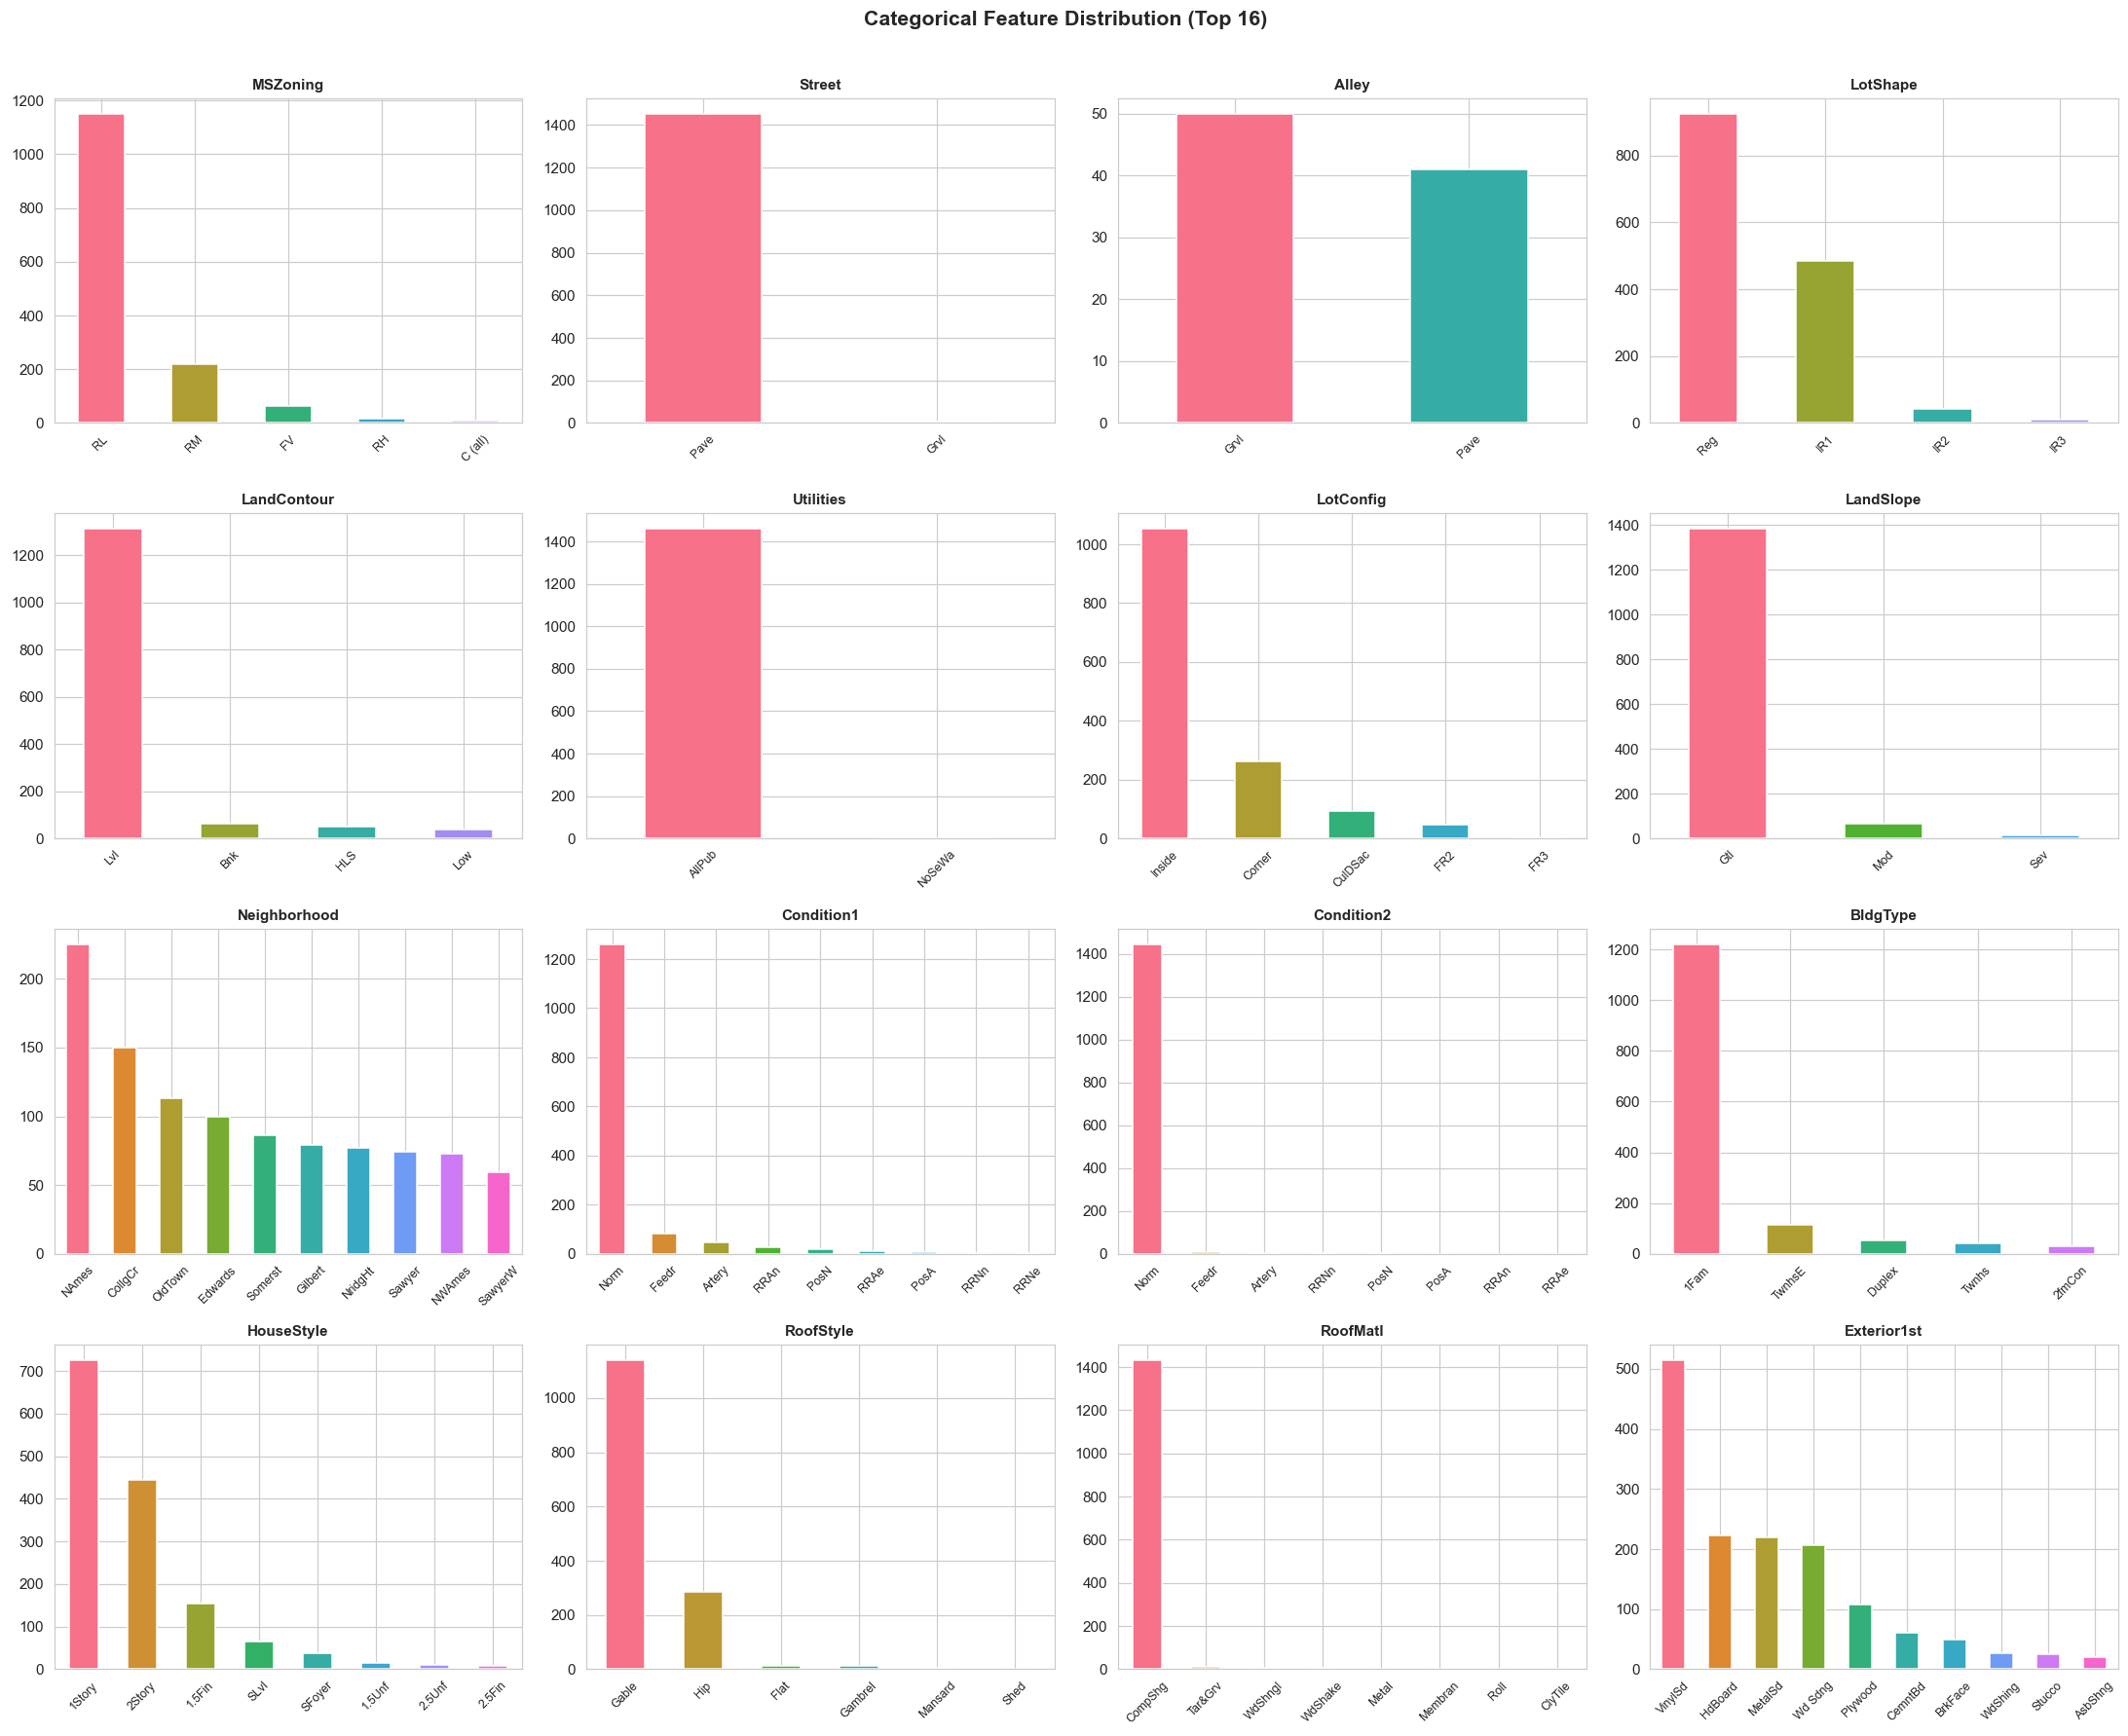

In [35]:
fig,axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.flatten()
top_cats = cat_cols[:16]

for i, col in enumerate(top_cats):
    vc = df[col].value_counts().head(10)
    vc.plot(kind='bar', ax=axes[i], color=sns.color_palette('husl', len(vc)), edgecolor='white')
    axes[i].set_title(col, fontweight='bold', fontsize=10)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45, labelsize=8)


plt.suptitle('Categorical Feature Distribution (Top 16)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()
    

In [36]:
# ============================================================
# 1.8 CORRELATION HEATMAP
# ============================================================

In [37]:
corr_matrix = df[num_cols + ['SalePrice']].corr()
corr_matrix

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
MSSubClass,1.000000,-0.386347,-0.139781,0.032628,-0.059316,0.027850,0.040581,0.022936,-0.069836,-0.065649,...,-0.012579,-0.006100,-0.012037,-0.043825,-0.026030,0.008283,-0.007683,-0.013585,-0.021407,-0.084284
LotFrontage,-0.386347,1.000000,0.426095,0.251646,-0.059213,0.123349,0.088866,0.193458,0.233633,0.049900,...,0.088521,0.151972,0.010700,0.070029,0.041383,0.206167,0.003368,0.011200,0.007450,0.351799
LotArea,-0.139781,0.426095,1.000000,0.105806,-0.005636,0.014228,0.013788,0.104160,0.214103,0.111170,...,0.171698,0.084774,-0.018340,0.020423,0.043160,0.077672,0.038068,0.001205,-0.014261,0.263843
OverallQual,0.032628,0.251646,0.105806,1.000000,-0.091932,0.572323,0.550684,0.411876,0.239666,-0.059119,...,0.238923,0.308819,-0.113937,0.030371,0.064886,0.065166,-0.031406,0.070815,-0.027347,0.790982
OverallCond,-0.059316,-0.059213,-0.005636,-0.091932,1.000000,-0.375983,0.073741,-0.128101,-0.046231,0.040229,...,-0.003334,-0.032589,0.070356,0.025504,0.054811,-0.001985,0.068777,-0.003511,0.043950,-0.077856
YearBuilt,0.027850,0.123349,0.014228,0.572323,-0.375983,1.000000,0.592855,0.315707,0.249503,-0.049107,...,0.224880,0.188686,-0.387268,0.031355,-0.050364,0.004950,-0.034383,0.012398,-0.013618,0.522897
YearRemodAdd,0.040581,0.088866,0.013788,0.550684,0.073741,0.592855,1.000000,0.179618,0.128451,-0.067759,...,0.205726,0.226298,-0.193919,0.045286,-0.038740,0.005829,-0.010286,0.021490,0.035743,0.507101
MasVnrArea,0.022936,0.193458,0.104160,0.411876,-0.128101,0.315707,0.179618,1.000000,0.264736,-0.072319,...,0.159718,0.125703,-0.110204,0.018796,0.061466,0.011723,-0.029815,-0.005965,-0.008201,0.477493
BsmtFinSF1,-0.069836,0.233633,0.214103,0.239666,-0.046231,0.249503,0.128451,0.264736,1.000000,-0.050117,...,0.204306,0.111761,-0.102303,0.026451,0.062021,0.140491,0.003571,-0.015727,0.014359,0.386420
BsmtFinSF2,-0.065649,0.049900,0.111170,-0.059119,0.040229,-0.049107,-0.067759,-0.072319,-0.050117,1.000000,...,0.067898,0.003093,0.036543,-0.029993,0.088871,0.041709,0.004940,-0.015211,0.031706,-0.011378


In [38]:
top_corr = corr_matrix['SalePrice'].abs().sort_values(ascending=False).head(21).index
top_corr

Index(['SalePrice', 'OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea',
       'TotalBsmtSF', '1stFlrSF', 'FullBath', 'TotRmsAbvGrd', 'YearBuilt',
       'YearRemodAdd', 'GarageYrBlt', 'MasVnrArea', 'Fireplaces', 'BsmtFinSF1',
       'LotFrontage', 'WoodDeckSF', '2ndFlrSF', 'OpenPorchSF', 'HalfBath',
       'LotArea'],
      dtype='object')

In [39]:
# Full correlation with SalePrice

In [40]:
corr_sale = corr_matrix['SalePrice'].drop('SalePrice').sort_values()
corr_sale

KitchenAbvGr    -0.135907
EnclosedPorch   -0.128578
MSSubClass      -0.084284
OverallCond     -0.077856
YrSold          -0.028923
LowQualFinSF    -0.025606
MiscVal         -0.021190
BsmtHalfBath    -0.016844
BsmtFinSF2      -0.011378
3SsnPorch        0.044584
MoSold           0.046432
PoolArea         0.092404
ScreenPorch      0.111447
BedroomAbvGr     0.168213
BsmtUnfSF        0.214479
BsmtFullBath     0.227122
LotArea          0.263843
HalfBath         0.284108
OpenPorchSF      0.315856
2ndFlrSF         0.319334
WoodDeckSF       0.324413
LotFrontage      0.351799
BsmtFinSF1       0.386420
Fireplaces       0.466929
MasVnrArea       0.477493
GarageYrBlt      0.486362
YearRemodAdd     0.507101
YearBuilt        0.522897
TotRmsAbvGrd     0.533723
FullBath         0.560664
1stFlrSF         0.605852
TotalBsmtSF      0.613581
GarageArea       0.623431
GarageCars       0.640409
GrLivArea        0.708624
OverallQual      0.790982
Name: SalePrice, dtype: float64

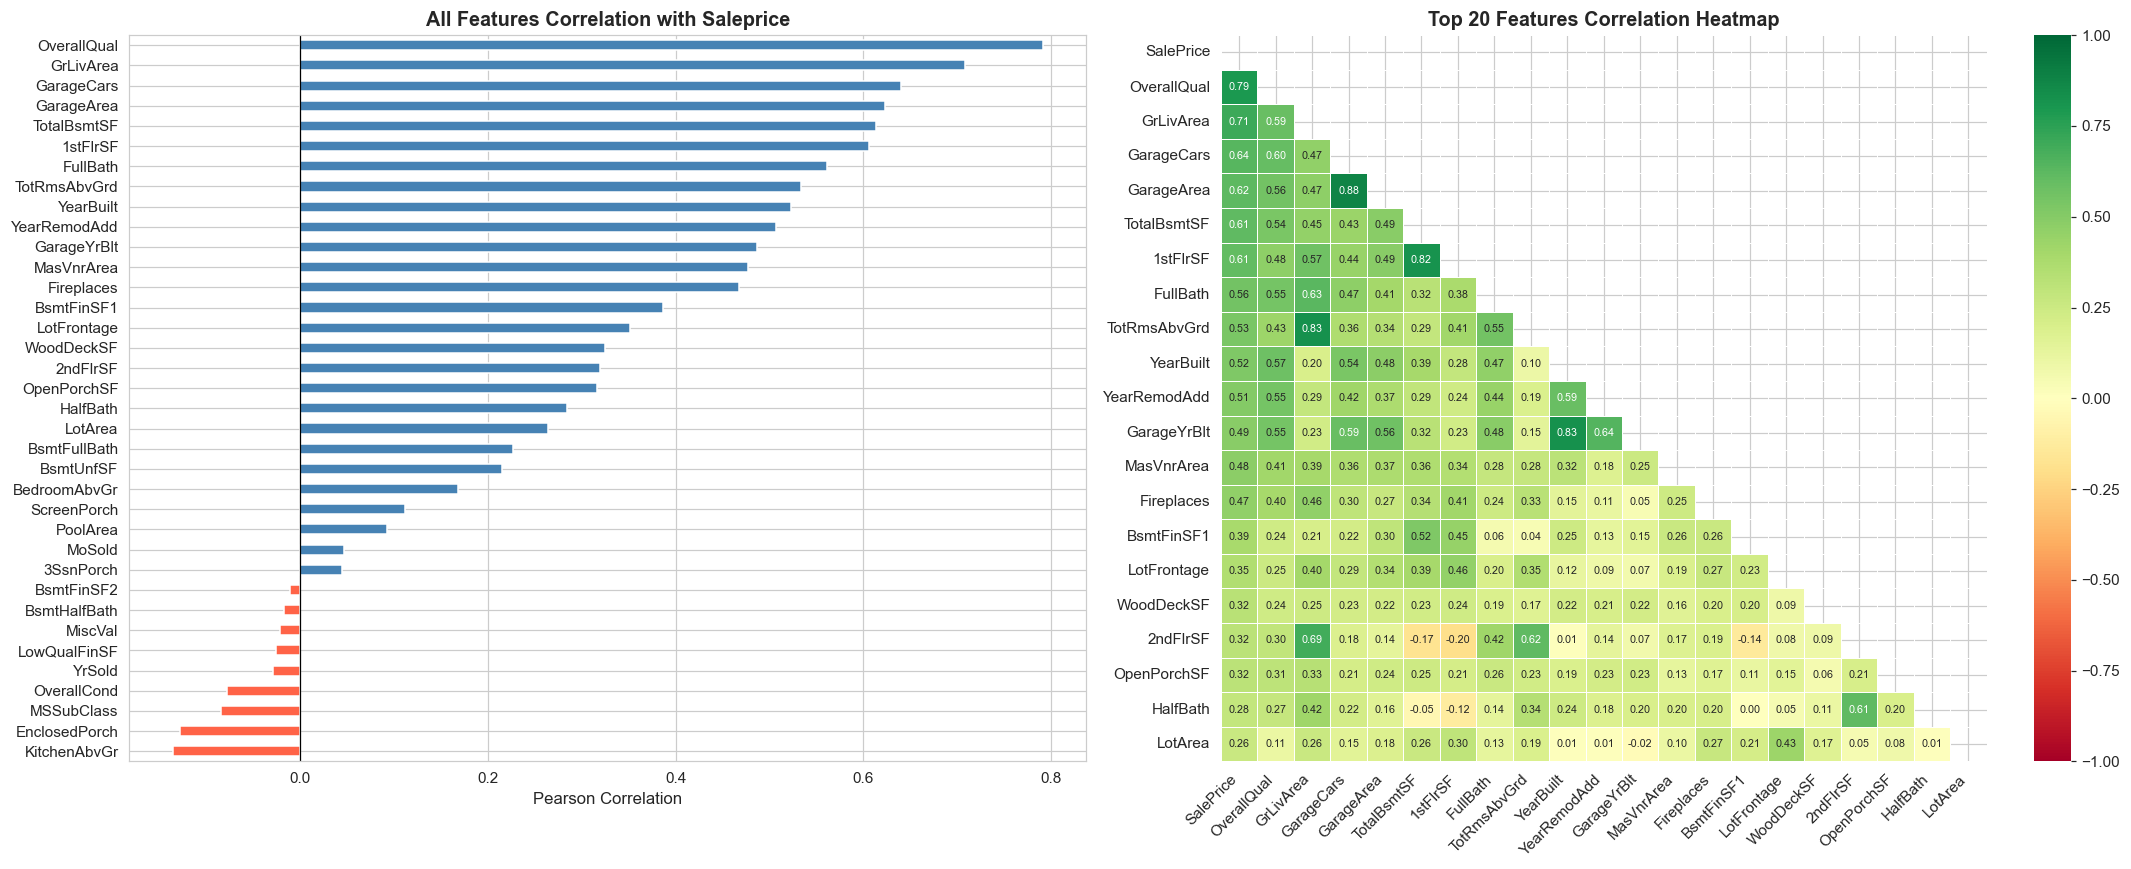

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
corr_sale = corr_matrix['SalePrice'].drop('SalePrice').sort_values()
colors = ['tomato' if x < 0 else 'steelblue' for x in corr_sale.values]
corr_sale.plot(kind='barh',
               ax=axes[0],
               color=colors,
               edgecolor='white'
              )
axes[0].set_title('All Features Correlation with Saleprice', fontweight='bold')
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_xlabel('Pearson Correlation')


mask = np.triu(np.ones_like(corr_matrix.loc[top_corr, top_corr], dtype=bool))
sns.heatmap(corr_matrix.loc[top_corr, top_corr],
            mask=mask,
            annot=True,
            fmt='.2f',
            cmap='RdYlGn',
            ax=axes[1],
            linewidths=0.5,
            annot_kws={'size':7},
            vmin=-1,
            vmax=1,
            center=0
           )
axes[1].set_title('Top 20 Features Correlation Heatmap', fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [42]:
# ============================================================
# 1.9 OUTLIER DETECTION
# ============================================================

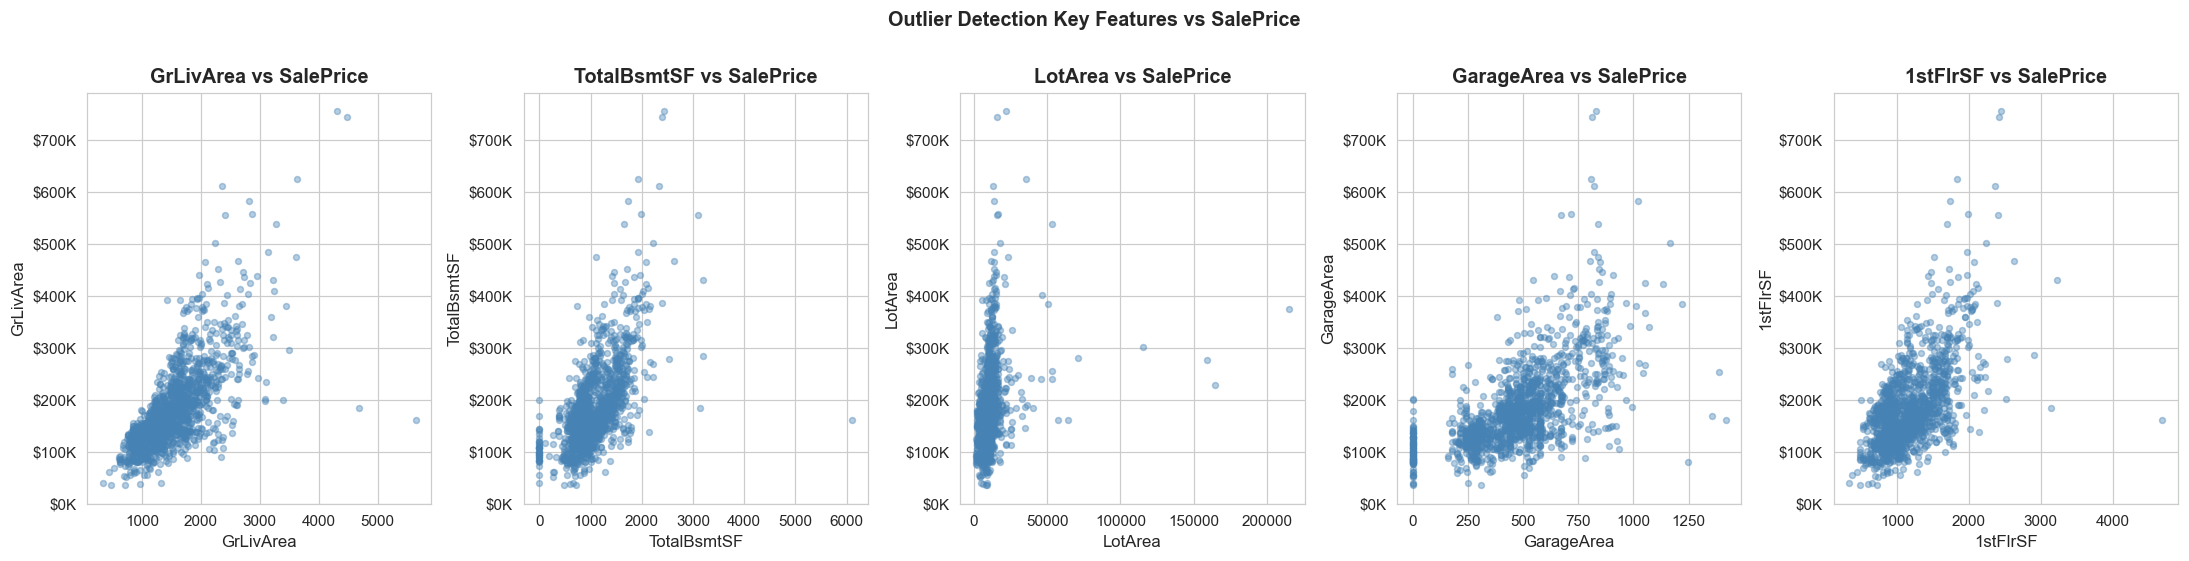

IQR-Based Outlier Count In Numerical Features:
 MSSubClass: 103 outliers (7.1%)
 LotFrontage: 88 outliers (6.0%)
 LotArea: 69 outliers (4.7%)
 OverallQual: 2 outliers (0.1%)
 OverallCond: 125 outliers (8.6%)
 YearBuilt: 7 outliers (0.5%)
 MasVnrArea: 96 outliers (6.6%)
 BsmtFinSF1: 7 outliers (0.5%)
 BsmtFinSF2: 167 outliers (11.4%)
 BsmtUnfSF: 29 outliers (2.0%)
 TotalBsmtSF: 61 outliers (4.2%)
 1stFlrSF: 20 outliers (1.4%)
 2ndFlrSF: 2 outliers (0.1%)
 LowQualFinSF: 26 outliers (1.8%)
 GrLivArea: 31 outliers (2.1%)
 BsmtFullBath: 1 outliers (0.1%)
 BsmtHalfBath: 82 outliers (5.6%)
 BedroomAbvGr: 35 outliers (2.4%)
 KitchenAbvGr: 68 outliers (4.7%)
 TotRmsAbvGrd: 30 outliers (2.1%)
 Fireplaces: 5 outliers (0.3%)
 GarageCars: 5 outliers (0.3%)
 GarageArea: 21 outliers (1.4%)
 WoodDeckSF: 32 outliers (2.2%)
 OpenPorchSF: 77 outliers (5.3%)
 EnclosedPorch: 208 outliers (14.2%)
 3SsnPorch: 24 outliers (1.6%)
 ScreenPorch: 116 outliers (7.9%)
 PoolArea: 7 outliers (0.5%)
 MiscVal: 52 outli

In [43]:
key_features = ['GrLivArea', 'TotalBsmtSF', 'LotArea', 'GarageArea', '1stFlrSF']

fog,axes = plt.subplots(1, len(key_features), figsize=(20,5))
for i, col in enumerate(key_features):
    axes[i].scatter(df[col],
                    df['SalePrice'],
                    alpha=0.4,
                    color='steelblue',
                    s=15
                   )
    axes[i].set_xlabel(col)
    axes[i].set_ylabel(col)
    axes[i].set_title(f'{col} vs SalePrice', fontweight='bold')
    axes[i].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

plt.suptitle('Outlier Detection Key Features vs SalePrice', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


print('IQR-Based Outlier Count In Numerical Features:')
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    outliers = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    if outliers > 0:
        print(f' {col}: {outliers} outliers ({outliers/len(df)*100:.1f}%)')


In [44]:
# ============================================================
# 1.10 TIME-BASED ANALYSIS
# ============================================================

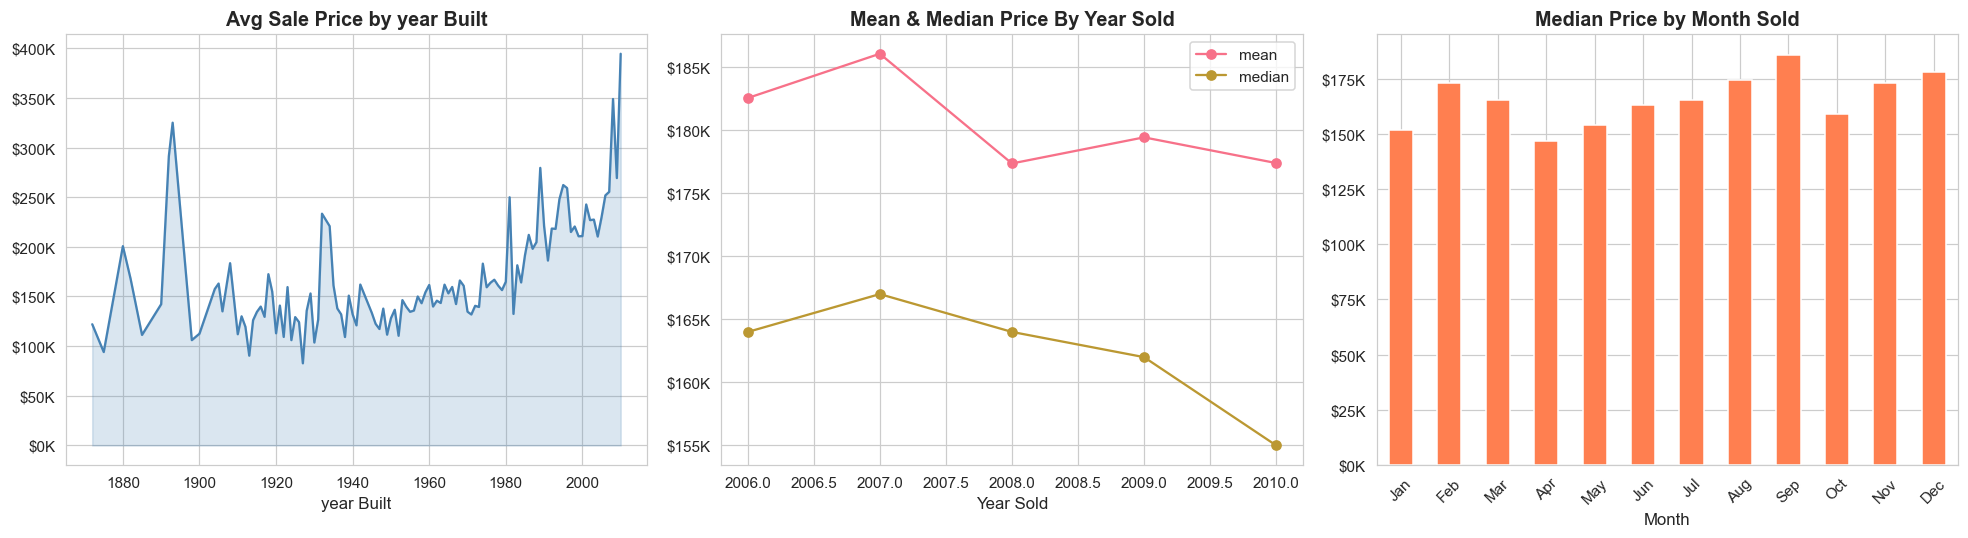

In [45]:
fig,axes = plt.subplots(1, 3, figsize=(18,5))

# Avg price by year built

yr_built = df.groupby('YearBuilt')['SalePrice'].mean()
axes[0].plot(yr_built.index,
             yr_built.values,
             color='steelblue',
             linewidth=1.5
            )
axes[0].fill_between(yr_built.index,
                     yr_built.values,
                     alpha=0.2,
                     color='steelblue'
                    )
axes[0].set_title('Avg Sale Price by year Built', fontweight='bold')
axes[0].set_xlabel('year Built')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))


# Price by year sold
yr_sold = df.groupby('YrSold')['SalePrice'].agg(['mean', 'median'])
yr_sold.plot(ax=axes[1],
             marker='o'
            )
axes[1].set_title('Mean & Median Price By Year Sold', fontweight='bold')
axes[1].set_xlabel('Year Sold')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))



# Price by month sold
mo_sold = df.groupby('MoSold')['SalePrice'].median()
mo_sold.plot(kind='bar',
             ax=axes[2],
             color='coral',
             edgecolor='white',
            )

axes[2].set_title('Median Price by Month Sold', fontweight='bold')
axes[2].set_xlabel('Month')
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
axes[2].set_xticklabels(month_names, rotation=45)

plt.tight_layout()
plt.show()




In [46]:
# ============================================================
# 1.11 NEIGHBORHOOD ANALYSIS
# ============================================================

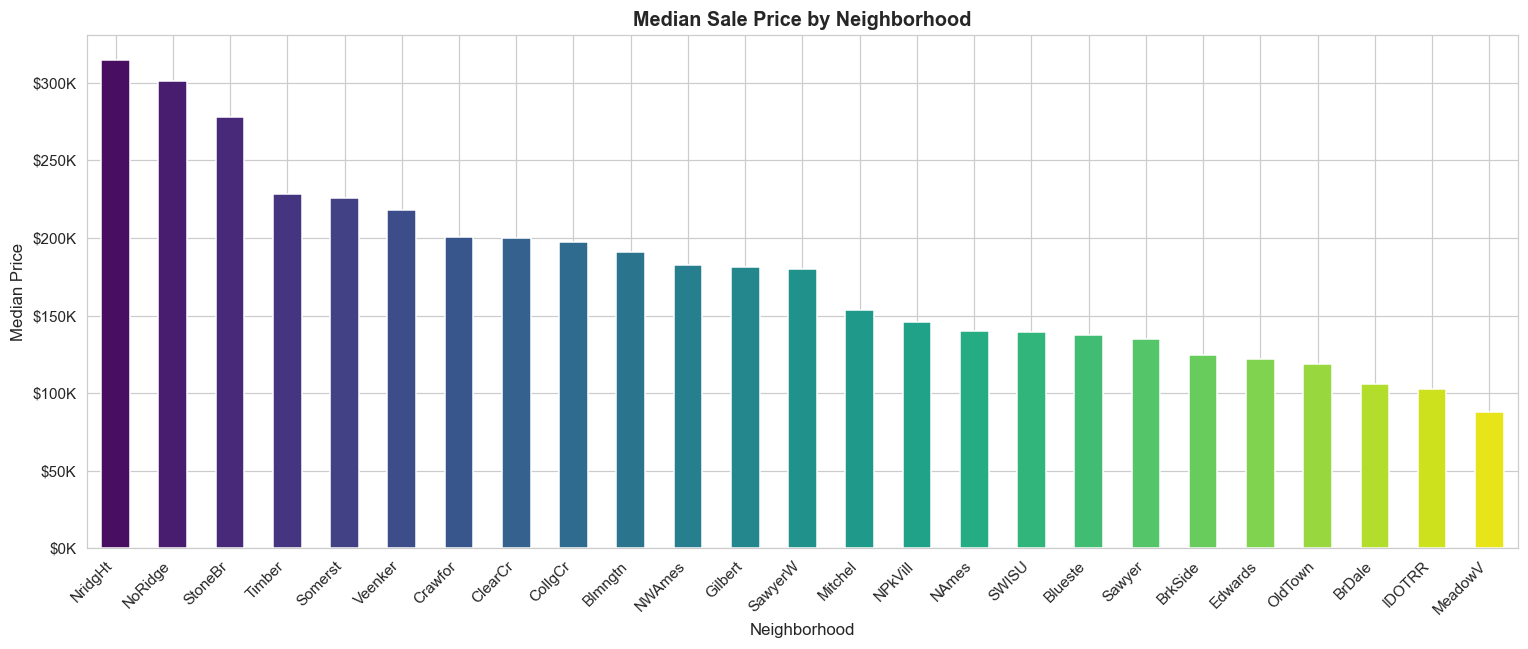

Top 5 Most Expensive Neighborhoods:
                median           mean  count
Neighborhood                                
NridgHt       315000.0  316270.623377     77
NoRidge       301500.0  335295.317073     41
StoneBr       278000.0  310499.000000     25
Timber        228475.0  242247.447368     38
Somerst       225500.0  225379.837209     86

Top 5 Most Affordable Neighborhoods:
                median           mean  count
Neighborhood                                
Edwards       121750.0  128219.700000    100
OldTown       119000.0  128225.300885    113
BrDale        106000.0  104493.750000     16
IDOTRR        103000.0  100123.783784     37
MeadowV        88000.0   98576.470588     17


In [47]:
nbhd = df.groupby('Neighborhood')['SalePrice'].agg(['median', 'mean', 'count']).sort_values('median',ascending=False)

fig,ax = plt.subplots(figsize=(14,6))
nbhd['median'].plot(kind='bar',
                    ax=ax,
                    color=sns.color_palette('viridis', len(nbhd)),
                    edgecolor='white'
                   )
ax.set_title('Median Sale Price by Neighborhood', fontweight='bold')
ax.set_xlabel('Neighborhood')
ax.set_ylabel('Median Price')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('Top 5 Most Expensive Neighborhoods:')
print(nbhd.head())
print('\nTop 5 Most Affordable Neighborhoods:')
print(nbhd.tail())


In [48]:
# ============================================================
# 1.12 QUALITY & CONDITION ANALYSIS
# ============================================================

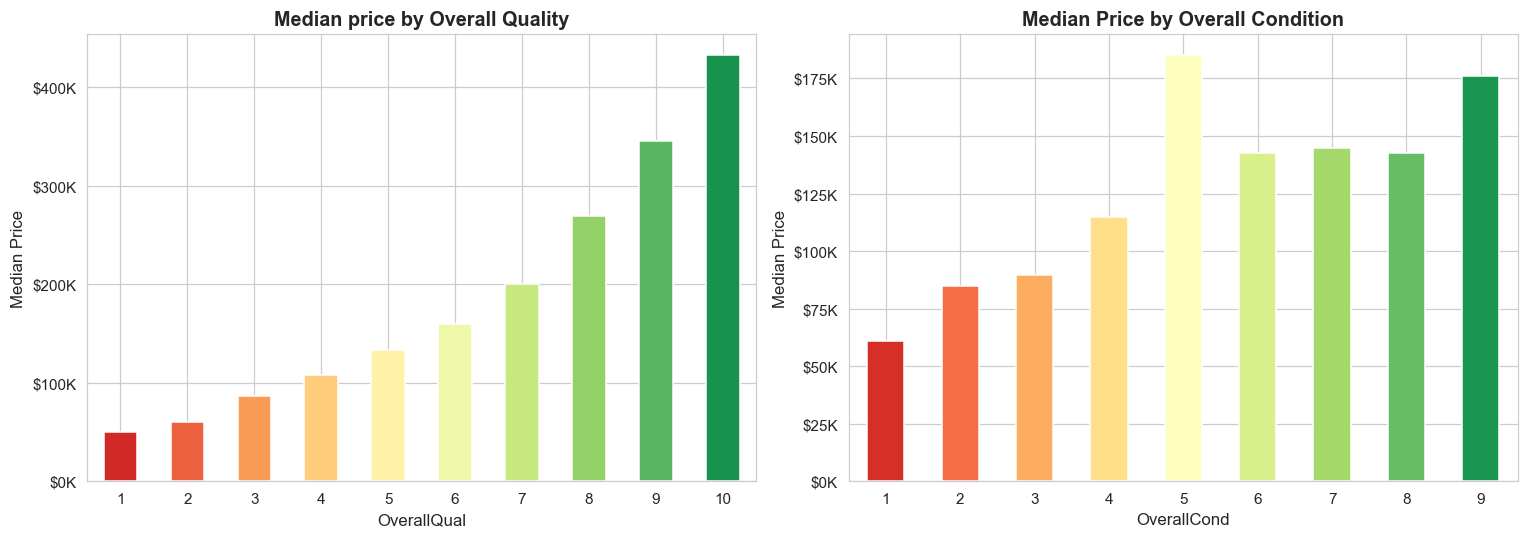

In [49]:
fig,ax = plt.subplots(1, 2, figsize=(14,5))

for col,ax, title in [
    ('OverallQual', ax[0], 'Median price by Overall Quality'),
    ('OverallCond', ax[1], 'Median Price by Overall Condition')
]:
    data = df.groupby(col)['SalePrice'].median()
    colors = sns.color_palette('RdYlGn', len(data))
    data.plot(kind='bar',
              ax=ax,
              color=colors,
              edgecolor='white'
             )
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Median Price')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
    ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()
     

In [50]:
# TASK 2 -- Feature Engineering & Model Building

In [51]:
df_model = df.copy()
df_model

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


In [52]:
# Drop Id column

df_model.drop('Id', axis=1, inplace=True)

In [53]:
# Remove extreme outliers (large house with low price)

df_model = df_model[~((df_model['GrLivArea'] > 4000) & (df_model['SalePrice'] < 200000))]
print(df_model)

      MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0             60       RL         65.0     8450   Pave   NaN      Reg   
1             20       RL         80.0     9600   Pave   NaN      Reg   
2             60       RL         68.0    11250   Pave   NaN      IR1   
3             70       RL         60.0     9550   Pave   NaN      IR1   
4             60       RL         84.0    14260   Pave   NaN      IR1   
...          ...      ...          ...      ...    ...   ...      ...   
1455          60       RL         62.0     7917   Pave   NaN      Reg   
1456          20       RL         85.0    13175   Pave   NaN      Reg   
1457          70       RL         66.0     9042   Pave   NaN      Reg   
1458          20       RL         68.0     9717   Pave   NaN      Reg   
1459          20       RL         75.0     9937   Pave   NaN      Reg   

     LandContour Utilities LotConfig  ... PoolArea PoolQC  Fence MiscFeature  \
0            Lvl    AllPub    Inside  ...  

In [54]:
print(f'shape after outlier removal: {df_model.shape}')

shape after outlier removal: (1458, 80)


In [55]:
# Log-transform target variable

df_model['SalePrice'] = np.log1p(df_model['SalePrice'])
print('Target variable log_transformed')

Target variable log_transformed


In [56]:
# ============================================================
# 2.2 MISSING VALUE IMPUTATION
# ============================================================

In [57]:
none_fill_cols = [
    'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
    'MasVnrType'
]
for col in none_fill_cols:
    if col in df_model.columns:
        df_model[col] = df_model[col].fillna('None')


num_fill_cols = ['LotFrontage', 'MasVnrArea', 'GarageYrBlt', 'GarageArea',
                 'GarageCars', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF',
                 'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath']

for col in num_fill_cols:
    if col in df_model.columns:
        df_model[col] = df_model[col].fillna(df_model[col].median())

        
df_model['LotFrontage'] = df_model.groupby('Neighborhood')['LotFrontage'].transform(
    lambda x: x.fillna(x.median())
)

cat_miss = df_model.select_dtypes(include='object').columns[df_model.select_dtypes(include='object').isnull().any()]

for col in cat_miss:
    df_model[col] = df_model[col].fillna(df_model[col].mode()[0])


print(f'Missing Values after imputation: {df_model.isnull().sum().sum()}')    

        

Missing Values after imputation: 0


In [58]:
# ============================================================
# 2.3 FEATURE ENGINEERING
# ============================================================

In [59]:
# Total area

In [60]:
df_model['TotalSF'] = df_model['TotalBsmtSF'] + df_model['1stFlrSF'] + df_model['2ndFlrSF']
df_model

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,TotalSF
0,60,RL,65.0,8450,Pave,None,Reg,Lvl,AllPub,Inside,...,None,None,None,0,2,2008,WD,Normal,12.247699,2566
1,20,RL,80.0,9600,Pave,None,Reg,Lvl,AllPub,FR2,...,None,None,None,0,5,2007,WD,Normal,12.109016,2524
2,60,RL,68.0,11250,Pave,None,IR1,Lvl,AllPub,Inside,...,None,None,None,0,9,2008,WD,Normal,12.317171,2706
3,70,RL,60.0,9550,Pave,None,IR1,Lvl,AllPub,Corner,...,None,None,None,0,2,2006,WD,Abnorml,11.849405,2473
4,60,RL,84.0,14260,Pave,None,IR1,Lvl,AllPub,FR2,...,None,None,None,0,12,2008,WD,Normal,12.429220,3343
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,60,RL,62.0,7917,Pave,None,Reg,Lvl,AllPub,Inside,...,None,None,None,0,8,2007,WD,Normal,12.072547,2600
1456,20,RL,85.0,13175,Pave,None,Reg,Lvl,AllPub,Inside,...,None,MnPrv,None,0,2,2010,WD,Normal,12.254868,3615
1457,70,RL,66.0,9042,Pave,None,Reg,Lvl,AllPub,Inside,...,None,GdPrv,Shed,2500,5,2010,WD,Normal,12.493133,3492
1458,20,RL,68.0,9717,Pave,None,Reg,Lvl,AllPub,Inside,...,None,None,None,0,4,2010,WD,Normal,11.864469,2156


In [61]:
# Total bathrooms

In [62]:

df_model['TotalBath'] = (df_model['FullBath'] + 0.5 * df_model['HalfBath'] + df_model['3SsnPorch'] + 0.5 * df_model['BsmtHalfBath'])
df_model

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,TotalSF,TotalBath
0,60,RL,65.0,8450,Pave,None,Reg,Lvl,AllPub,Inside,...,None,None,0,2,2008,WD,Normal,12.247699,2566,2.5
1,20,RL,80.0,9600,Pave,None,Reg,Lvl,AllPub,FR2,...,None,None,0,5,2007,WD,Normal,12.109016,2524,2.5
2,60,RL,68.0,11250,Pave,None,IR1,Lvl,AllPub,Inside,...,None,None,0,9,2008,WD,Normal,12.317171,2706,2.5
3,70,RL,60.0,9550,Pave,None,IR1,Lvl,AllPub,Corner,...,None,None,0,2,2006,WD,Abnorml,11.849405,2473,1.0
4,60,RL,84.0,14260,Pave,None,IR1,Lvl,AllPub,FR2,...,None,None,0,12,2008,WD,Normal,12.429220,3343,2.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,60,RL,62.0,7917,Pave,None,Reg,Lvl,AllPub,Inside,...,None,None,0,8,2007,WD,Normal,12.072547,2600,2.5
1456,20,RL,85.0,13175,Pave,None,Reg,Lvl,AllPub,Inside,...,MnPrv,None,0,2,2010,WD,Normal,12.254868,3615,2.0
1457,70,RL,66.0,9042,Pave,None,Reg,Lvl,AllPub,Inside,...,GdPrv,Shed,2500,5,2010,WD,Normal,12.493133,3492,2.0
1458,20,RL,68.0,9717,Pave,None,Reg,Lvl,AllPub,Inside,...,None,None,0,4,2010,WD,Normal,11.864469,2156,1.0


In [63]:
# Total porch area

In [64]:
df_model['TotalPorchSF'] = (df_model['OpenPorchSF'] + df_model['EnclosedPorch'] + df_model['3SsnPorch'] + df_model['ScreenPorch'])
df_model    

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,TotalSF,TotalBath,TotalPorchSF
0,60,RL,65.0,8450,Pave,None,Reg,Lvl,AllPub,Inside,...,None,0,2,2008,WD,Normal,12.247699,2566,2.5,61
1,20,RL,80.0,9600,Pave,None,Reg,Lvl,AllPub,FR2,...,None,0,5,2007,WD,Normal,12.109016,2524,2.5,0
2,60,RL,68.0,11250,Pave,None,IR1,Lvl,AllPub,Inside,...,None,0,9,2008,WD,Normal,12.317171,2706,2.5,42
3,70,RL,60.0,9550,Pave,None,IR1,Lvl,AllPub,Corner,...,None,0,2,2006,WD,Abnorml,11.849405,2473,1.0,307
4,60,RL,84.0,14260,Pave,None,IR1,Lvl,AllPub,FR2,...,None,0,12,2008,WD,Normal,12.429220,3343,2.5,84
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,60,RL,62.0,7917,Pave,None,Reg,Lvl,AllPub,Inside,...,None,0,8,2007,WD,Normal,12.072547,2600,2.5,40
1456,20,RL,85.0,13175,Pave,None,Reg,Lvl,AllPub,Inside,...,None,0,2,2010,WD,Normal,12.254868,3615,2.0,0
1457,70,RL,66.0,9042,Pave,None,Reg,Lvl,AllPub,Inside,...,Shed,2500,5,2010,WD,Normal,12.493133,3492,2.0,60
1458,20,RL,68.0,9717,Pave,None,Reg,Lvl,AllPub,Inside,...,None,0,4,2010,WD,Normal,11.864469,2156,1.0,112


In [65]:
# House age features

In [66]:
df_model['HouseAge'] = df_model['YrSold'] - df_model['YearBuilt']
df_model['YearsSinceRemodel'] = df_model['YrSold'] - df_model['YearRemodAdd']
df_model['IsRemodeled'] = (df_model['YearBuilt'] != df_model['YearRemodAdd']).astype(int)
df_model

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,YrSold,SaleType,SaleCondition,SalePrice,TotalSF,TotalBath,TotalPorchSF,HouseAge,YearsSinceRemodel,IsRemodeled
0,60,RL,65.0,8450,Pave,None,Reg,Lvl,AllPub,Inside,...,2008,WD,Normal,12.247699,2566,2.5,61,5,5,0
1,20,RL,80.0,9600,Pave,None,Reg,Lvl,AllPub,FR2,...,2007,WD,Normal,12.109016,2524,2.5,0,31,31,0
2,60,RL,68.0,11250,Pave,None,IR1,Lvl,AllPub,Inside,...,2008,WD,Normal,12.317171,2706,2.5,42,7,6,1
3,70,RL,60.0,9550,Pave,None,IR1,Lvl,AllPub,Corner,...,2006,WD,Abnorml,11.849405,2473,1.0,307,91,36,1
4,60,RL,84.0,14260,Pave,None,IR1,Lvl,AllPub,FR2,...,2008,WD,Normal,12.429220,3343,2.5,84,8,8,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,60,RL,62.0,7917,Pave,None,Reg,Lvl,AllPub,Inside,...,2007,WD,Normal,12.072547,2600,2.5,40,8,7,1
1456,20,RL,85.0,13175,Pave,None,Reg,Lvl,AllPub,Inside,...,2010,WD,Normal,12.254868,3615,2.0,0,32,22,1
1457,70,RL,66.0,9042,Pave,None,Reg,Lvl,AllPub,Inside,...,2010,WD,Normal,12.493133,3492,2.0,60,69,4,1
1458,20,RL,68.0,9717,Pave,None,Reg,Lvl,AllPub,Inside,...,2010,WD,Normal,11.864469,2156,1.0,112,60,14,1


In [67]:
# Has pool, garage, basement, 2nd floor

In [68]:
df_model['HasPool'] = (df_model['PoolArea'] > 0).astype(int)
df_model['HasGarage'] = (df_model['GarageArea'] > 0).astype(int)
df_model['HasBasement'] = (df_model['TotalBsmtSF'] > 0).astype(int)
df_model['Has2ndFloor'] = (df_model['2ndFlrSF'] > 0).astype(int)
df_model['HasFireplace'] = (df_model['Fireplaces'] > 0).astype(int)
df_model


,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,TotalBath,TotalPorchSF,HouseAge,YearsSinceRemodel,IsRemodeled,HasPool,HasGarage,HasBasement,Has2ndFloor,HasFireplace
0,60,RL,65.0,8450,Pave,None,Reg,Lvl,AllPub,Inside,...,2.5,61,5,5,0,0,1,1,1,0
1,20,RL,80.0,9600,Pave,None,Reg,Lvl,AllPub,FR2,...,2.5,0,31,31,0,0,1,1,0,1
2,60,RL,68.0,11250,Pave,None,IR1,Lvl,AllPub,Inside,...,2.5,42,7,6,1,0,1,1,1,1
3,70,RL,60.0,9550,Pave,None,IR1,Lvl,AllPub,Corner,...,1.0,307,91,36,1,0,1,1,1,1
4,60,RL,84.0,14260,Pave,None,IR1,Lvl,AllPub,FR2,...,2.5,84,8,8,0,0,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,60,RL,62.0,7917,Pave,None,Reg,Lvl,AllPub,Inside,...,2.5,40,8,7,1,0,1,1,1,1
1456,20,RL,85.0,13175,Pave,None,Reg,Lvl,AllPub,Inside,...,2.0,0,32,22,1,0,1,1,0,1
1457,70,RL,66.0,9042,Pave,None,Reg,Lvl,AllPub,Inside,...,2.0,60,69,4,1,0,1,1,1,1
1458,20,RL,68.0,9717,Pave,None,Reg,Lvl,AllPub,Inside,...,1.0,112,60,14,1,0,1,1,0,0


In [69]:
# Quality-Area interactions
df_model['QualXArea'] = df_model['OverallQual'] * df_model['GrLivArea']
df_model['QualXTotalSF'] = df_model['OverallQual'] * df_model['TotalSF']
df_model

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,HouseAge,YearsSinceRemodel,IsRemodeled,HasPool,HasGarage,HasBasement,Has2ndFloor,HasFireplace,QualXArea,QualXTotalSF
0,60,RL,65.0,8450,Pave,None,Reg,Lvl,AllPub,Inside,...,5,5,0,0,1,1,1,0,11970,17962
1,20,RL,80.0,9600,Pave,None,Reg,Lvl,AllPub,FR2,...,31,31,0,0,1,1,0,1,7572,15144
2,60,RL,68.0,11250,Pave,None,IR1,Lvl,AllPub,Inside,...,7,6,1,0,1,1,1,1,12502,18942
3,70,RL,60.0,9550,Pave,None,IR1,Lvl,AllPub,Corner,...,91,36,1,0,1,1,1,1,12019,17311
4,60,RL,84.0,14260,Pave,None,IR1,Lvl,AllPub,FR2,...,8,8,0,0,1,1,1,1,17584,26744
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,60,RL,62.0,7917,Pave,None,Reg,Lvl,AllPub,Inside,...,8,7,1,0,1,1,1,1,9882,15600
1456,20,RL,85.0,13175,Pave,None,Reg,Lvl,AllPub,Inside,...,32,22,1,0,1,1,0,1,12438,21690
1457,70,RL,66.0,9042,Pave,None,Reg,Lvl,AllPub,Inside,...,69,4,1,0,1,1,1,1,16380,24444
1458,20,RL,68.0,9717,Pave,None,Reg,Lvl,AllPub,Inside,...,60,14,1,0,1,1,0,0,5390,10780


In [70]:
print(f'Shape after feature engineering: {df_model.shape}')
print('New features created ')

Shape after feature engineering: (1458, 93)
New features created 


In [71]:
# ============================================================
# 2.4 ENCODING CATEGORICAL VARIABLES
# ============================================================

In [72]:
qual_map = {'EX' : 5, 'Gd' : 4, 'TA' : 3, 'Fa' : 2, 'Po': 1, 'None' : 0}
ordinals_cols =['ExterQual',
                'ExterCond',
                'BsmtQual',
                'BsmtCond',
                'HeatingQC',
                'KitchenQual',
                'FireplaceQu',
                'GarageQual',
                'GarageCond',
                'PoolQC'
               ]
for col in ordinals_cols:
    if col in df_model.columns:
        df_model[col] = df_model[col].map(qual_map).fillna(0).astype(int)

df_model['BsmtExposure'] = df_model['BsmtExposure'].map({'Gd':4,'Av':3,'Mn':2,'No':1,'None':0}).fillna(0).astype(int)


func_map = {'Typ':7,'Min1':6,'Min2':5,'Mod':4,'Maj1':3,'Maj2':2,'Sev':1,'Sal':0}
df_model['Functional'] = df_model['Functional'].map(func_map).fillna(0)


df_model['PavedDrive'] = df_model['PavedDrive'].map({'Y':2,'P':1,'N':0}).fillna(0)


df_model['LandSlope'] = df_model['LandSlope'].map({'Gtl':1,'Mod':2,'Sev':3}).fillna(1)

cat_remaining = df_model.select_dtypes(include='object').columns.tolist()
df_model = pd.get_dummies(df_model, columns=cat_remaining, drop_first=True)

print(f'Shape after encoding: {df_model.shape}')
        
                
                

Shape after encoding: (1458, 232)


In [73]:
# ============================================================
# 2.5 LOG-TRANSFORM SKEWED NUMERICAL FEATURES
# ============================================================

In [74]:
num_feats = df_model.select_dtypes(include=[np.number]).columns.drop('SalePrice').tolist()
num_feats

['MSSubClass',
 'LotFrontage',
 'LotArea',
 'LandSlope',
 'OverallQual',
 'OverallCond',
 'YearBuilt',
 'YearRemodAdd',
 'MasVnrArea',
 'ExterQual',
 'ExterCond',
 'BsmtQual',
 'BsmtCond',
 'BsmtExposure',
 'BsmtFinSF1',
 'BsmtFinSF2',
 'BsmtUnfSF',
 'TotalBsmtSF',
 'HeatingQC',
 '1stFlrSF',
 '2ndFlrSF',
 'LowQualFinSF',
 'GrLivArea',
 'BsmtFullBath',
 'BsmtHalfBath',
 'FullBath',
 'HalfBath',
 'BedroomAbvGr',
 'KitchenAbvGr',
 'KitchenQual',
 'TotRmsAbvGrd',
 'Functional',
 'Fireplaces',
 'FireplaceQu',
 'GarageYrBlt',
 'GarageCars',
 'GarageArea',
 'GarageQual',
 'GarageCond',
 'PavedDrive',
 'WoodDeckSF',
 'OpenPorchSF',
 'EnclosedPorch',
 '3SsnPorch',
 'ScreenPorch',
 'PoolArea',
 'PoolQC',
 'MiscVal',
 'MoSold',
 'YrSold',
 'TotalSF',
 'TotalBath',
 'TotalPorchSF',
 'HouseAge',
 'YearsSinceRemodel',
 'IsRemodeled',
 'HasPool',
 'HasGarage',
 'HasBasement',
 'Has2ndFloor',
 'HasFireplace',
 'QualXArea',
 'QualXTotalSF']

In [75]:
skew_feats = df_model[num_feats].apply(lambda x: skew(x.dropna()))
skew_feats

MSSubClass       1.405563
LotFrontage      1.719086
LotArea         12.560986
LandSlope        4.805032
OverallQual      0.200579
                  ...    
HasBasement     -6.035847
Has2ndFloor      0.276967
HasFireplace    -0.107149
QualXArea        1.492289
QualXTotalSF     1.391617
Length: 63, dtype: float64

In [76]:
skew_feats = skew_feats[abs(skew_feats) > 0.75].index
skew_feats

Index(['MSSubClass', 'LotFrontage', 'LotArea', 'LandSlope', 'MasVnrArea',
       'ExterQual', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtHalfBath', 'KitchenAbvGr', 'KitchenQual',
       'Functional', 'GarageQual', 'GarageCond', 'PavedDrive', 'WoodDeckSF',
       'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea',
       'PoolQC', 'MiscVal', 'TotalSF', 'TotalBath', 'TotalPorchSF', 'HasPool',
       'HasGarage', 'HasBasement', 'QualXArea', 'QualXTotalSF'],
      dtype='object')

In [77]:
for col in skew_feats:
    df_model[col] = np.log1p(df_model[col].clip(lower=0))

print(f'Log_transformed {len(skew_feats)} skewed features')    

Log_transformed 39 skewed features


In [78]:
# ============================================================
# 2.6 TRAIN-TEST SPLIT
# ============================================================

In [79]:
X = df_model.drop('SalePrice', axis=1)
y = df_model['SalePrice']

X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.2, random_state=SEED)

print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')

scaler = RobustScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

print('Data split and scaled')

Train: (1166, 231)  |  Test: (292, 231)
Data split and scaled


In [80]:
# ============================================================
# 2.7 MODEL TRAINING & EVALUATION FUNCTION
# ============================================================

In [81]:
def evaluate_model(name,model, X_train, X_test, y_train, y_test,  cv=5):

    kf = KFold(n_splits=cv,
               shuffle=True,
               random_state=SEED
              )
    cv_scores = cross_val_score(model,
                                X_train,
                                y_train,
                                cv=kf,
                                scoring='neg_root_mean_squared_error'
                               )
    cv_rmse = -cv_scores.mean()
    cv_std = cv_scores.std()


    model.fit(X_train, y_train)
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)


    train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    test_mae = mean_absolute_error(y_test, y_pred_test)
    test_r2 = r2_score(y_test, y_pred_test)


    print(f' {''*60}')
    print(f'Model: {name}')
    print(f'  CV RMSE (log):    {cv_rmse:.4f} ± {cv_std:.4f}')
    print(f'  Train RMSE   :    {train_rmse:.4f}')
    print(f'  Test  RMSE   :    {test_rmse:.4f}')
    print(f'  Test  MAE    :    {test_mae:.4f}')
    print(f'  Test   R²    :    {test_r2:.4f}')

    return {
        'Model'      : name,
        'CV RMSE'    : round(cv_rmse, 4),
        'CV Std'     : round(train_rmse, 4),
        'Train RMSE' : round(test_rmse, 4),
        'Test RMSE'  : round(test_mae, 4),
        'Test R²'    : round(test_r2, 4),
        'model_obj'  : model,
        'y_pred'     : y_pred_test
    }


results = []
print('Evaluation function defined')
         
    

    

Evaluation function defined


In [82]:
# ============================================================
# 2.8 LINEAR MODELS
# ============================================================

In [83]:
results.append(
    evaluate_model
    ('Linear Regression',
     LinearRegression(),
     X_train_sc,
     X_test_sc,
     y_train,
     y_test))

results.append(
    evaluate_model
    ('Ridge Regression (α=10)',
    Ridge(alpha=10,
          random_state=SEED),
    X_train_sc,
    X_test_sc,
    y_train,
    y_test))

results.append(
    evaluate_model
    ('Lasso Regression (α=0.001)',
     Lasso(alpha=0.001,
           random_state=SEED,
           max_iter=5000),
     X_train_sc,
     X_test_sc,
     y_train,
     y_test))

results.append(
    evaluate_model
    ('ElasticNet (α=0.001)',
     ElasticNet(alpha=0.001,
                l1_ratio=0.5,
                random_state=SEED,
                max_iter=5000),
     X_train_sc,
     X_test_sc,
     y_train,
     y_test))
     
     
     
     

     
     
    


 
Model: Linear Regression
  CV RMSE (log):    0.1269 ± 0.0134
  Train RMSE   :    0.0877
  Test  RMSE   :    0.1359
  Test  MAE    :    0.0867
  Test   R²    :    0.8905
 
Model: Ridge Regression (α=10)
  CV RMSE (log):    0.1129 ± 0.0076
  Train RMSE   :    0.0968
  Test  RMSE   :    0.1170
  Test  MAE    :    0.0781
  Test   R²    :    0.9188
 
Model: Lasso Regression (α=0.001)
  CV RMSE (log):    0.1130 ± 0.0078
  Train RMSE   :    0.1042
  Test  RMSE   :    0.1138
  Test  MAE    :    0.0771
  Test   R²    :    0.9231
 
Model: ElasticNet (α=0.001)
  CV RMSE (log):    0.1118 ± 0.0073
  Train RMSE   :    0.0996
  Test  RMSE   :    0.1135
  Test  MAE    :    0.0761
  Test   R²    :    0.9235


In [ ]:
# ============================================================
# 2.9 TREE-BASED MODELS
# ============================================================

In [93]:
results.append(
    evaluate_model(
        'Decision Tree',
        DecisionTreeRegressor(
            max_depth=8,
            random_state=SEED),
        X_train,
        X_test,
        y_train,
        y_test))
        
           
        
           
results.append(
    evaluate_model(
        'Random Forest',
        RandomForestRegressor(
            n_estimators=200,
            max_depth=None,
            min_samples_split=2,
            random_state=SEED,
            n_jobs=-1),
        X_train,
        X_test,
        y_train,
        y_test))

results.append(
    evaluate_model(
        'Extra Trees',
        ExtraTreesRegressor(
            n_estimators=200,
            random_state=SEED,
            n_jobs=-1),
        X_train,
        X_test,
        y_train,
        y_test))

results.append(
    evaluate_model(
        'Gradient Boosting',
        GradientBoostingRegressor(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=4,
            random_state=SEED),
        X_train,
        X_test,
        y_train,
        y_test))
        
    

 
Model: Decision Tree
  CV RMSE (log):    0.1920 ± 0.0140
  Train RMSE   :    0.0829
  Test  RMSE   :    0.1673
  Test  MAE    :    0.1208
  Test   R²    :    0.8340
 
Model: Random Forest
  CV RMSE (log):    0.1363 ± 0.0099
  Train RMSE   :    0.0498
  Test  RMSE   :    0.1402
  Test  MAE    :    0.0929
  Test   R²    :    0.8834
 
Model: Extra Trees
  CV RMSE (log):    0.1290 ± 0.0124
  Train RMSE   :    0.0000
  Test  RMSE   :    0.1380
  Test  MAE    :    0.0911
  Test   R²    :    0.8871
 
Model: Gradient Boosting
  CV RMSE (log):    0.1206 ± 0.0103
  Train RMSE   :    0.0458
  Test  RMSE   :    0.1268
  Test  MAE    :    0.0855
  Test   R²    :    0.9047


In [84]:
# ============================================================
# 2.10 ADVANCED BOOSTING MODELS
# ============================================================

In [85]:
!pip install xgboost lightgbm

Defaulting to user installation because normal site-packages is not writeable


In [94]:
import xgboost as xgb
import lightgbm as lgb

results.append(
    evaluate_model(
        'XGBoost',
        xgb.XGBRegressor(
            n_estimators=500,
            learning_rate=0.05,
            max_depth=4,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_alpha=0.01,
            reg_lambda=1,
            random_state=SEED,
            verbosity=0
        ),
        X_train,
        X_test,
        y_train,
        y_test
    )
)


results.append(
    evaluate_model(
        'LightGBM',
        lgb.LGBMRegressor(
            n_estimators=500,
            learning_rate=0.05,
            num_leaves=31,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_alpha=0.01,
            reg_lambda=1,
            random_state=SEED,
            verbose=-1
        ),
        X_train,
        X_test,
        y_train,
        y_test
    )
)

 
Model: XGBoost
  CV RMSE (log):    0.1167 ± 0.0121
  Train RMSE   :    0.0309
  Test  RMSE   :    0.1261
  Test  MAE    :    0.0833
  Test   R²    :    0.9056
 
Model: LightGBM
  CV RMSE (log):    0.1255 ± 0.0106
  Train RMSE   :    0.0145
  Test  RMSE   :    0.1308
  Test  MAE    :    0.0861
  Test   R²    :    0.8985


In [ ]:
# ============================================================
# 2.11 MODEL COMPARISON REPORT
# ============================================================

In [95]:
report_df = pd.DataFrame([{k: v for k, v in r.items() if k not in ['model_obj', 'y_pred']} for r in results])
report_df

,Model,CV RMSE,CV Std,Train RMSE,Test RMSE,Test R²
0,Linear Regression,0.1269,0.0877,0.1359,0.0867,0.8905
1,Ridge Regression (α=10),0.1129,0.0968,0.1170,0.0781,0.9188
2,Lasso Regression (α=0.001),0.1130,0.1042,0.1138,0.0771,0.9231
3,ElasticNet (α=0.001),0.1118,0.0996,0.1135,0.0761,0.9235
4,XGBoost,0.1167,0.0309,0.1261,0.0833,0.9056
5,LightGBM,0.1255,0.0145,0.1308,0.0861,0.8985
6,Decision Tree,0.1920,0.0829,0.1673,0.1208,0.8340
7,Random Forest,0.1363,0.0498,0.1402,0.0929,0.8834
8,Extra Trees,0.1290,0.0000,0.1380,0.0911,0.8871
9,Gradient Boosting,0.1206,0.0458,0.1268,0.0855,0.9047


In [96]:
report_df = report_df.sort_values('Test RMSE')
report_df

,Model,CV RMSE,CV Std,Train RMSE,Test RMSE,Test R²
3,ElasticNet (α=0.001),0.1118,0.0996,0.1135,0.0761,0.9235
2,Lasso Regression (α=0.001),0.1130,0.1042,0.1138,0.0771,0.9231
1,Ridge Regression (α=10),0.1129,0.0968,0.1170,0.0781,0.9188
4,XGBoost,0.1167,0.0309,0.1261,0.0833,0.9056
10,XGBoost,0.1167,0.0309,0.1261,0.0833,0.9056
9,Gradient Boosting,0.1206,0.0458,0.1268,0.0855,0.9047
5,LightGBM,0.1255,0.0145,0.1308,0.0861,0.8985
11,LightGBM,0.1255,0.0145,0.1308,0.0861,0.8985
0,Linear Regression,0.1269,0.0877,0.1359,0.0867,0.8905
8,Extra Trees,0.1290,0.0000,0.1380,0.0911,0.8871


In [97]:
report_df = report_df.reset_index(drop=True)
report_df

,Model,CV RMSE,CV Std,Train RMSE,Test RMSE,Test R²
0,ElasticNet (α=0.001),0.1118,0.0996,0.1135,0.0761,0.9235
1,Lasso Regression (α=0.001),0.1130,0.1042,0.1138,0.0771,0.9231
2,Ridge Regression (α=10),0.1129,0.0968,0.1170,0.0781,0.9188
3,XGBoost,0.1167,0.0309,0.1261,0.0833,0.9056
4,XGBoost,0.1167,0.0309,0.1261,0.0833,0.9056
5,Gradient Boosting,0.1206,0.0458,0.1268,0.0855,0.9047
6,LightGBM,0.1255,0.0145,0.1308,0.0861,0.8985
7,LightGBM,0.1255,0.0145,0.1308,0.0861,0.8985
8,Linear Regression,0.1269,0.0877,0.1359,0.0867,0.8905
9,Extra Trees,0.1290,0.0000,0.1380,0.0911,0.8871


In [99]:
print('\n' +  '=' * 70)
print('               MODEL COMPARISION REPORT')
print('='*70)
print(report_df.to_string(index=False))
print('='*70)

best = report_df.iloc[0]
print(f'\n Best Model: { best['Model'] }   |  Test R²: {best['Test R²']}  | Test RMSE : {best['Test RMSE']}')
report_df.style.background_gradient(subset=['Test RMSE','Test R²'], cmap='RdYlGn_r')


               MODEL COMPARISION REPORT
                     Model  CV RMSE  CV Std  Train RMSE  Test RMSE  Test R²
      ElasticNet (α=0.001)   0.1118  0.0996      0.1135     0.0761   0.9235
Lasso Regression (α=0.001)   0.1130  0.1042      0.1138     0.0771   0.9231
   Ridge Regression (α=10)   0.1129  0.0968      0.1170     0.0781   0.9188
                   XGBoost   0.1167  0.0309      0.1261     0.0833   0.9056
                   XGBoost   0.1167  0.0309      0.1261     0.0833   0.9056
         Gradient Boosting   0.1206  0.0458      0.1268     0.0855   0.9047
                  LightGBM   0.1255  0.0145      0.1308     0.0861   0.8985
                  LightGBM   0.1255  0.0145      0.1308     0.0861   0.8985
         Linear Regression   0.1269  0.0877      0.1359     0.0867   0.8905
               Extra Trees   0.1290  0.0000      0.1380     0.0911   0.8871
             Random Forest   0.1363  0.0498      0.1402     0.0929   0.8834
             Decision Tree   0.1920  0.0829    

,Model,CV RMSE,CV Std,Train RMSE,Test RMSE,Test R²
0,ElasticNet (α=0.001),0.111800,0.099600,0.113500,0.076100,0.923500
1,Lasso Regression (α=0.001),0.113000,0.104200,0.113800,0.077100,0.923100
2,Ridge Regression (α=10),0.112900,0.096800,0.117000,0.078100,0.918800
3,XGBoost,0.116700,0.030900,0.126100,0.083300,0.905600
4,XGBoost,0.116700,0.030900,0.126100,0.083300,0.905600
5,Gradient Boosting,0.120600,0.045800,0.126800,0.085500,0.904700
6,LightGBM,0.125500,0.014500,0.130800,0.086100,0.898500
7,LightGBM,0.125500,0.014500,0.130800,0.086100,0.898500
8,Linear Regression,0.126900,0.087700,0.135900,0.086700,0.890500
9,Extra Trees,0.129000,0.000000,0.138000,0.091100,0.887100


In [ ]:
# ============================================================
# 2.12 MODEL COMPARISON — VISUAL
# ============================================================

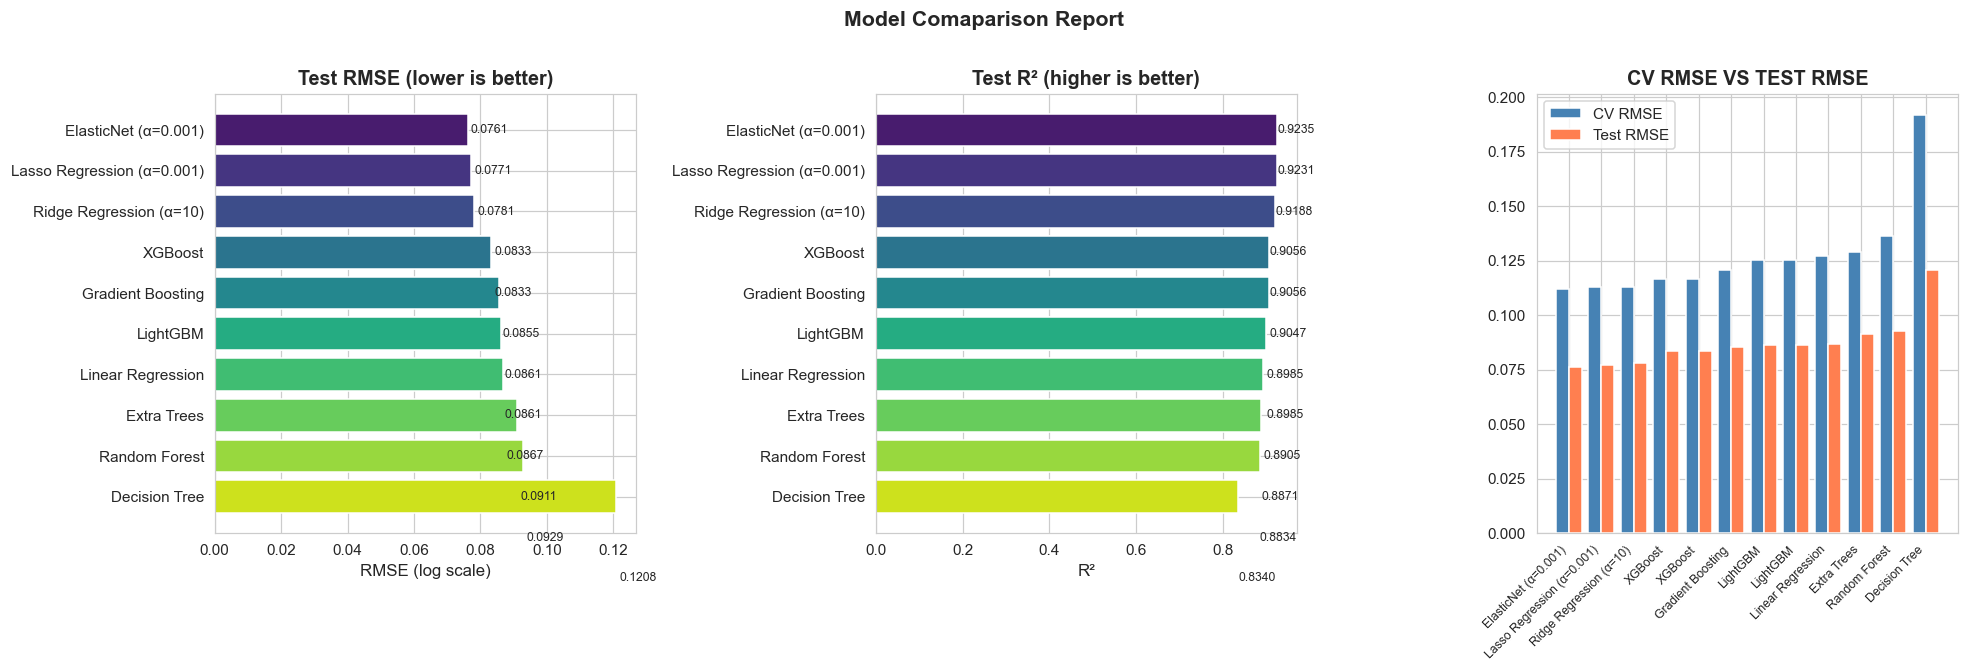

In [108]:
fig,axes = plt.subplots(1, 3, figsize=(18,6))

palette = sns.color_palette('viridis', len(report_df))

# RMSE comparison

axes[0].barh(report_df['Model'], report_df['Test RMSE'], color=palette, edgecolor='white')
axes[0].set_title('Test RMSE (lower is better)', fontweight='bold')
axes[0].set_xlabel('RMSE (log scale)')
axes[0].invert_yaxis()

for i, v in enumerate(report_df['Test RMSE']):
    axes[0].text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=8)


# R² comparison

axes[1].barh(report_df['Model'], report_df['Test R²'], color=palette, edgecolor='white')
axes[1].set_title('Test R² (higher is better)', fontweight='bold')
axes[1].set_xlabel('R²')
axes[1].invert_yaxis()
for i, v in enumerate(report_df['Test R²']):
    axes[1].text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=8)


# CV vs Test RMSE

x = range(len(report_df))
axes[2].bar([i - 0.2 for i in x], report_df['CV RMSE'], 0.4, label='CV RMSE', color='steelblue')
axes[2].bar([i + 0.2 for i in x], report_df['Test RMSE'], 0.4, label='Test RMSE', color='coral')
axes[2].set_xticks(x)
axes[2].set_xticklabels(report_df['Model'], rotation=45, ha='right', fontsize=8)
axes[2].set_title('CV RMSE VS TEST RMSE', fontweight='bold')
axes[2].legend()


plt.suptitle('Model Comaparison Report', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()



In [ ]:
# ============================================================
# 2.13 BEST MODEL — RESIDUAL ANALYSIS
# ============================================================

In [109]:
best_name = report_df.iloc[0]['Model']
best_name

'ElasticNet (α=0.001)'

In [110]:
best_result = next( r for r in results if r['Model'] == best_name)
best_result

{'Model': 'ElasticNet (α=0.001)',
 'CV RMSE': np.float64(0.1118),
 'CV Std': np.float64(0.0996),
 'Train RMSE': np.float64(0.1135),
 'Test RMSE': 0.0761,
 'Test R²': 0.9235,
 'model_obj': ElasticNet(alpha=0.001, max_iter=5000, random_state=42),
 'y_pred': array([12.36309516, 11.51674359, 11.55833959, 12.0236888 , 12.68042154,
        11.89835978, 12.42803563, 12.70210249, 12.55854217, 11.92420335,
        11.99789957, 12.12872733, 12.05170657, 12.55296521, 12.05900391,
        12.07569227, 12.16483696, 11.76289277, 11.73851802, 12.30210347,
        12.17941924, 12.20720768, 12.11543164, 12.25905695, 12.22247698,
        11.97886   , 12.1858597 , 11.57400236, 12.09770141, 12.04325031,
        11.77549215, 11.62687778, 12.13698964, 11.65275962, 12.48882428,
        12.56982678, 11.77843116, 12.22107146, 11.59502266, 11.55611198,
        11.74454921, 12.35209488, 11.64009199, 11.64656813, 11.7321396 ,
        12.01572594, 11.71203505, 11.80038394, 11.88280647, 11.97559591,
        11.8435

In [111]:
y_pred_best = best_result['y_pred']
y_pred_best

array([12.36309516, 11.51674359, 11.55833959, 12.0236888 , 12.68042154,
       11.89835978, 12.42803563, 12.70210249, 12.55854217, 11.92420335,
       11.99789957, 12.12872733, 12.05170657, 12.55296521, 12.05900391,
       12.07569227, 12.16483696, 11.76289277, 11.73851802, 12.30210347,
       12.17941924, 12.20720768, 12.11543164, 12.25905695, 12.22247698,
       11.97886   , 12.1858597 , 11.57400236, 12.09770141, 12.04325031,
       11.77549215, 11.62687778, 12.13698964, 11.65275962, 12.48882428,
       12.56982678, 11.77843116, 12.22107146, 11.59502266, 11.55611198,
       11.74454921, 12.35209488, 11.64009199, 11.64656813, 11.7321396 ,
       12.01572594, 11.71203505, 11.80038394, 11.88280647, 11.97559591,
       11.84354229, 11.36981135, 11.66130172, 11.87200519, 11.86506614,
       12.42183927, 12.24675046, 11.94890521, 11.83087697, 10.61522156,
       11.18561039, 12.20934226, 12.59043862, 12.45552607, 12.6408775 ,
       12.27166553, 11.58758121, 11.14837808, 11.79225906, 12.03

In [113]:
residuals = y_test.values - y_pred_best
residuals

array([-2.08310543e-01, -3.80812246e-03,  9.43565156e-02, -4.70230246e-02,
       -1.85044084e-02, -6.69733153e-02,  2.21122196e-01, -5.77716863e-02,
       -1.24286659e-02, -1.07469049e-01,  1.27723571e-02, -7.49262945e-02,
        1.51097517e-02,  1.12432374e-01,  4.72539270e-02, -1.05335627e-01,
       -4.48615597e-02,  5.01446943e-02,  6.48432221e-02,  2.61912297e-02,
        6.45580139e-03,  4.76598883e-02, -5.14929993e-02, -5.04824361e-02,
       -5.72211192e-02, -3.47951817e-02, -7.88618159e-02,  2.82519903e-01,
        8.55642068e-03,  6.17437049e-03, -2.35419141e-02,  8.27416221e-03,
        4.37703264e-02,  1.65817985e-01, -3.98015299e-02, -2.58579627e-03,
        1.59143139e-02,  7.80406117e-02,  3.12404217e-02, -7.36354133e-02,
       -9.62103702e-02, -1.21324740e-01,  5.09880268e-02,  3.61085473e-02,
        3.15523695e-02,  8.16528631e-02, -2.34686236e-02, -4.84337014e-02,
       -4.77902618e-02,  7.33943638e-03, -7.20984042e-02, -2.36668627e-01,
       -8.60561717e-03, -

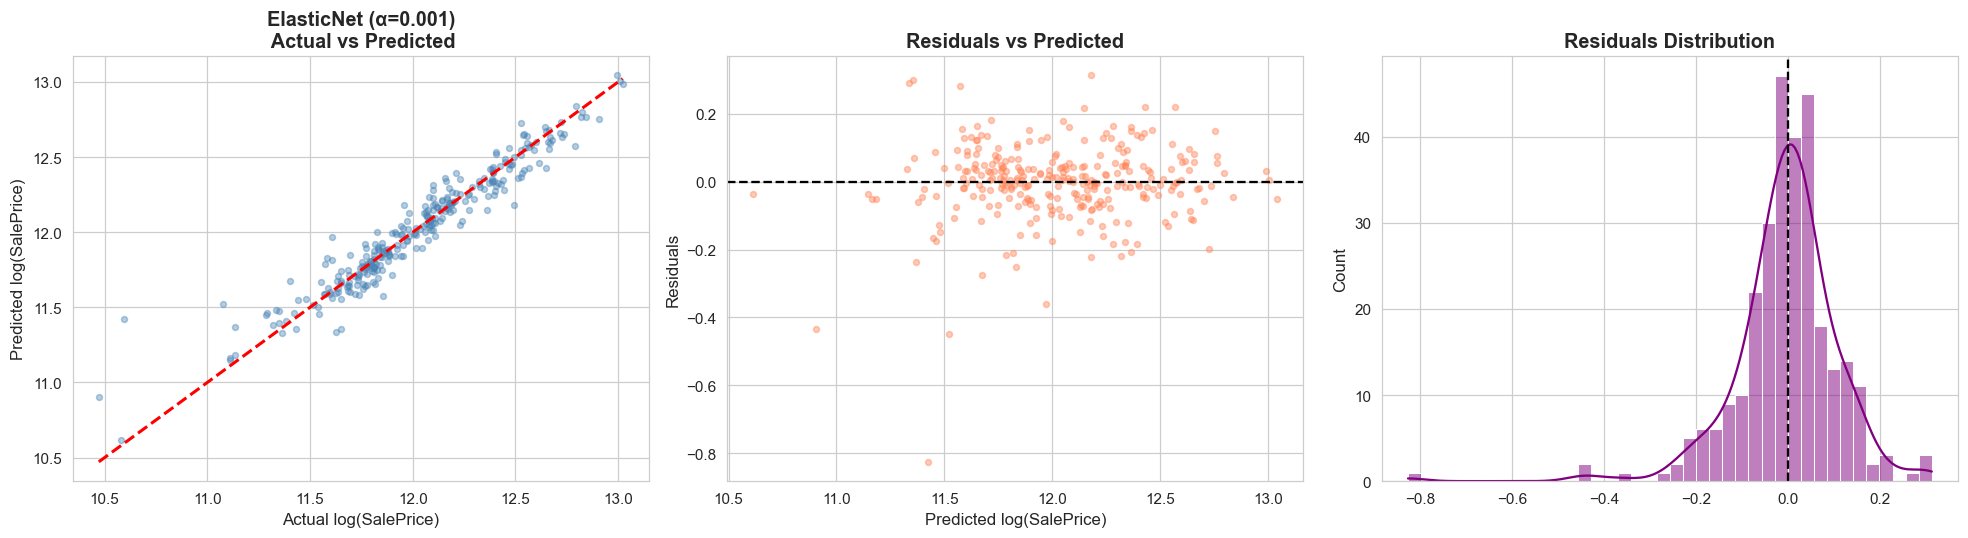

Best Model: ElasticNet (α=0.001)
RMSE on original scale: $18,385
MAE on original scale: $12,971


In [117]:
fig,axes = plt.subplots(1, 3, figsize=(18,5))

# Actual vs Predicted

axes[0].scatter(y_test, y_pred_best, alpha=0.4, color="steelblue", s=15)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual log(SalePrice)')
axes[0].set_ylabel('Predicted log(SalePrice)')
axes[0].set_title(f'{best_name}\n Actual vs Predicted', fontweight='bold')


# Residuals vs Predicted

axes[1].scatter(y_pred_best, residuals, alpha=0.4, color='coral', s=15)
axes[1].axhline(0, color='black', linestyle='--', lw=1.5)
axes[1].set_xlabel('Predicted log(SalePrice)')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residuals vs Predicted', fontweight='bold')

# Residual distribution

sns.histplot(residuals, kde=True, ax=axes[2], color='purple', bins=40)
axes[2].axvline(0, color='black', linestyle='--')
axes[2].set_title('Residuals Distribution', fontweight='bold')

plt.tight_layout()
plt.show()


# Predictions on original scale
actual_prices = np.expm1(y_test.values)
pred_prices = np.expm1(y_pred_best)
print(f'Best Model: {best_name}')
print(f'RMSE on original scale: ${np.sqrt(mean_squared_error(actual_prices, pred_prices)):,.0f}')
print(f'MAE on original scale: ${mean_absolute_error(actual_prices, pred_prices):,.0f}')


In [ ]:
# ============================================================
# 2.14 FEATURE IMPORTANCE
# ============================================================

In [122]:
best_obj = best_result['model_obj']
best_obj

,alpha,0.001
,l1_ratio,0.5
,fit_intercept,True
,precompute,False
,max_iter,5000
,copy_X,True
,tol,0.0001
,warm_start,False
,positive,False
,random_state,42
,selection,'cyclic'


In [121]:

if hasattr(best_obj, 'feature_importance_'):
    importances = pd.Series(best_obj.feature_importances_, index=X_train.columns)
else:
    importances = pd.Series(np.abs(best_obj.coef_), index=X_train.columns)


top_features = importances.sort_values(ascending=False).head(25)
top_features

Functional              0.132004
GrLivArea               0.126835
Neighborhood_Crawfor    0.104092
OverallQual             0.098140
Neighborhood_StoneBr    0.097653
SaleType_New            0.092850
Exterior1st_BrkFace     0.083639
MSZoning_FV             0.069038
Neighborhood_BrkSide    0.058682
HouseAge                0.057165
SaleCondition_Normal    0.056646
Neighborhood_NoRidge    0.053771
BldgType_Duplex         0.050096
TotalSF                 0.048715
OverallCond             0.047608
Condition1_Norm         0.043835
BsmtFinSF1              0.041932
CentralAir_Y            0.041878
YearBuilt               0.041271
BsmtFullBath            0.039109
TotalBsmtSF             0.038699
Neighborhood_Mitchel    0.038622
Foundation_PConc        0.038130
Condition1_RRAe         0.036315
RoofMatl_WdShngl        0.035791
dtype: float64

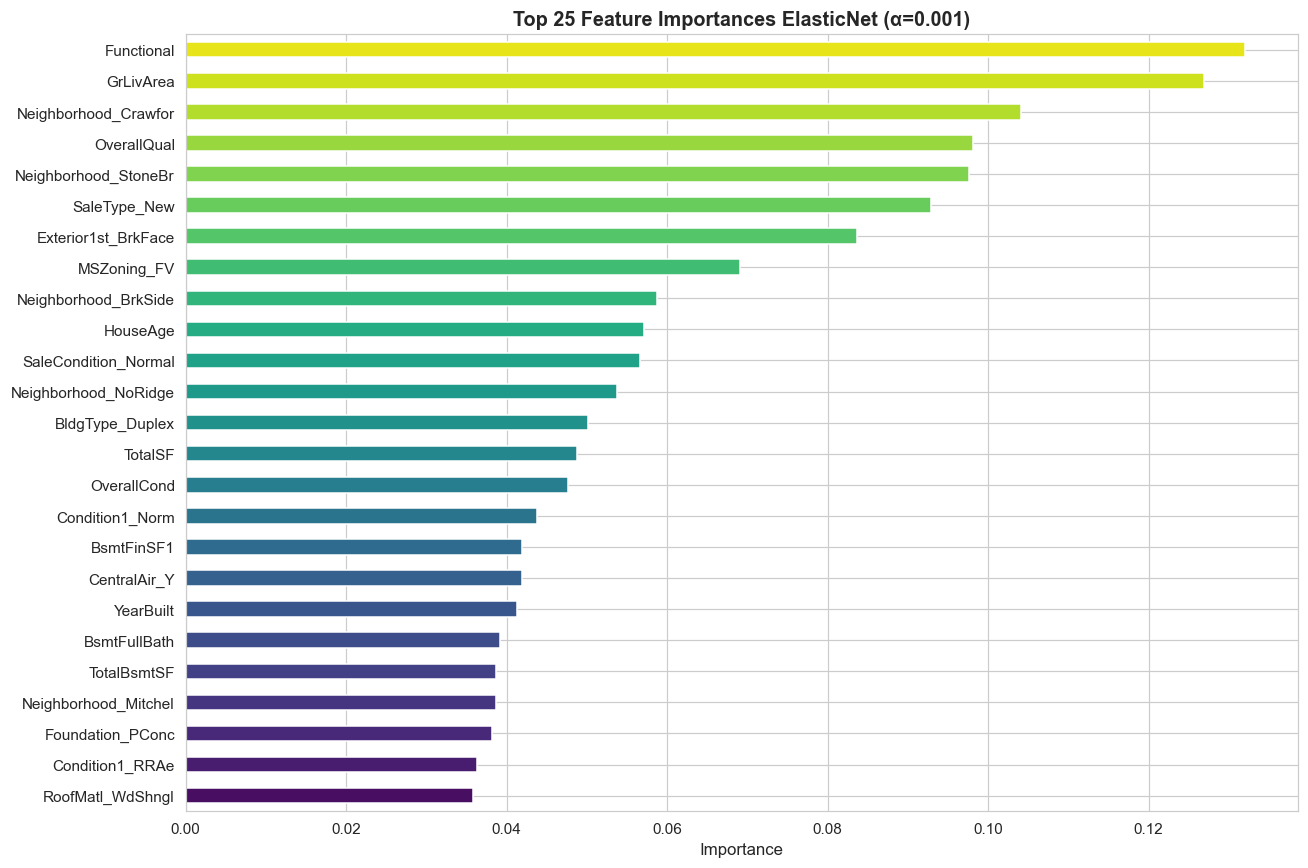

Top 10 Most Importance Features:
   1. Functional                     0.1320
   2. GrLivArea                      0.1268
   3. Neighborhood_Crawfor           0.1041
   4. OverallQual                    0.0981
   5. Neighborhood_StoneBr           0.0977
   6. SaleType_New                   0.0928
   7. Exterior1st_BrkFace            0.0836
   8. MSZoning_FV                    0.0690
   9. Neighborhood_BrkSide           0.0587
  10. HouseAge                       0.0572


In [125]:
best_obj = best_result['model_obj']
best_obj

if hasattr(best_obj, 'feature_importance_'):
    importances = pd.Series(best_obj.feature_importances_, index=X_train.columns)
else:
    importances = pd.Series(np.abs(best_obj.coef_), index=X_train.columns)


top_features = importances.sort_values(ascending=False).head(25)


fig,ax = plt.subplots(figsize=(12,8))
colors = sns.color_palette('viridis', len(top_features))
top_features.plot(kind='barh', ax=ax, color=colors[::-1], edgecolor='white')
ax.invert_yaxis()
ax.set_title(f'Top 25 Feature Importances {best_name}', fontweight='bold', fontsize=13)
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

print('Top 10 Most I
mportance Features:')
for i, (feat, imp) in enumerate(top_features.head(10).items(), 1):
    print(f'  {i:2d}. {feat:<30} {imp:.4f}')

In [ ]:
# TASK 2B - Relationship Between House Features and Price

In [ ]:
# ============================================================
# RELOAD ORIGINAL DF FOR RELATIONSHIP ANALYSIS
# ============================================================

In [126]:
df_orig = df.copy()
df_orig

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


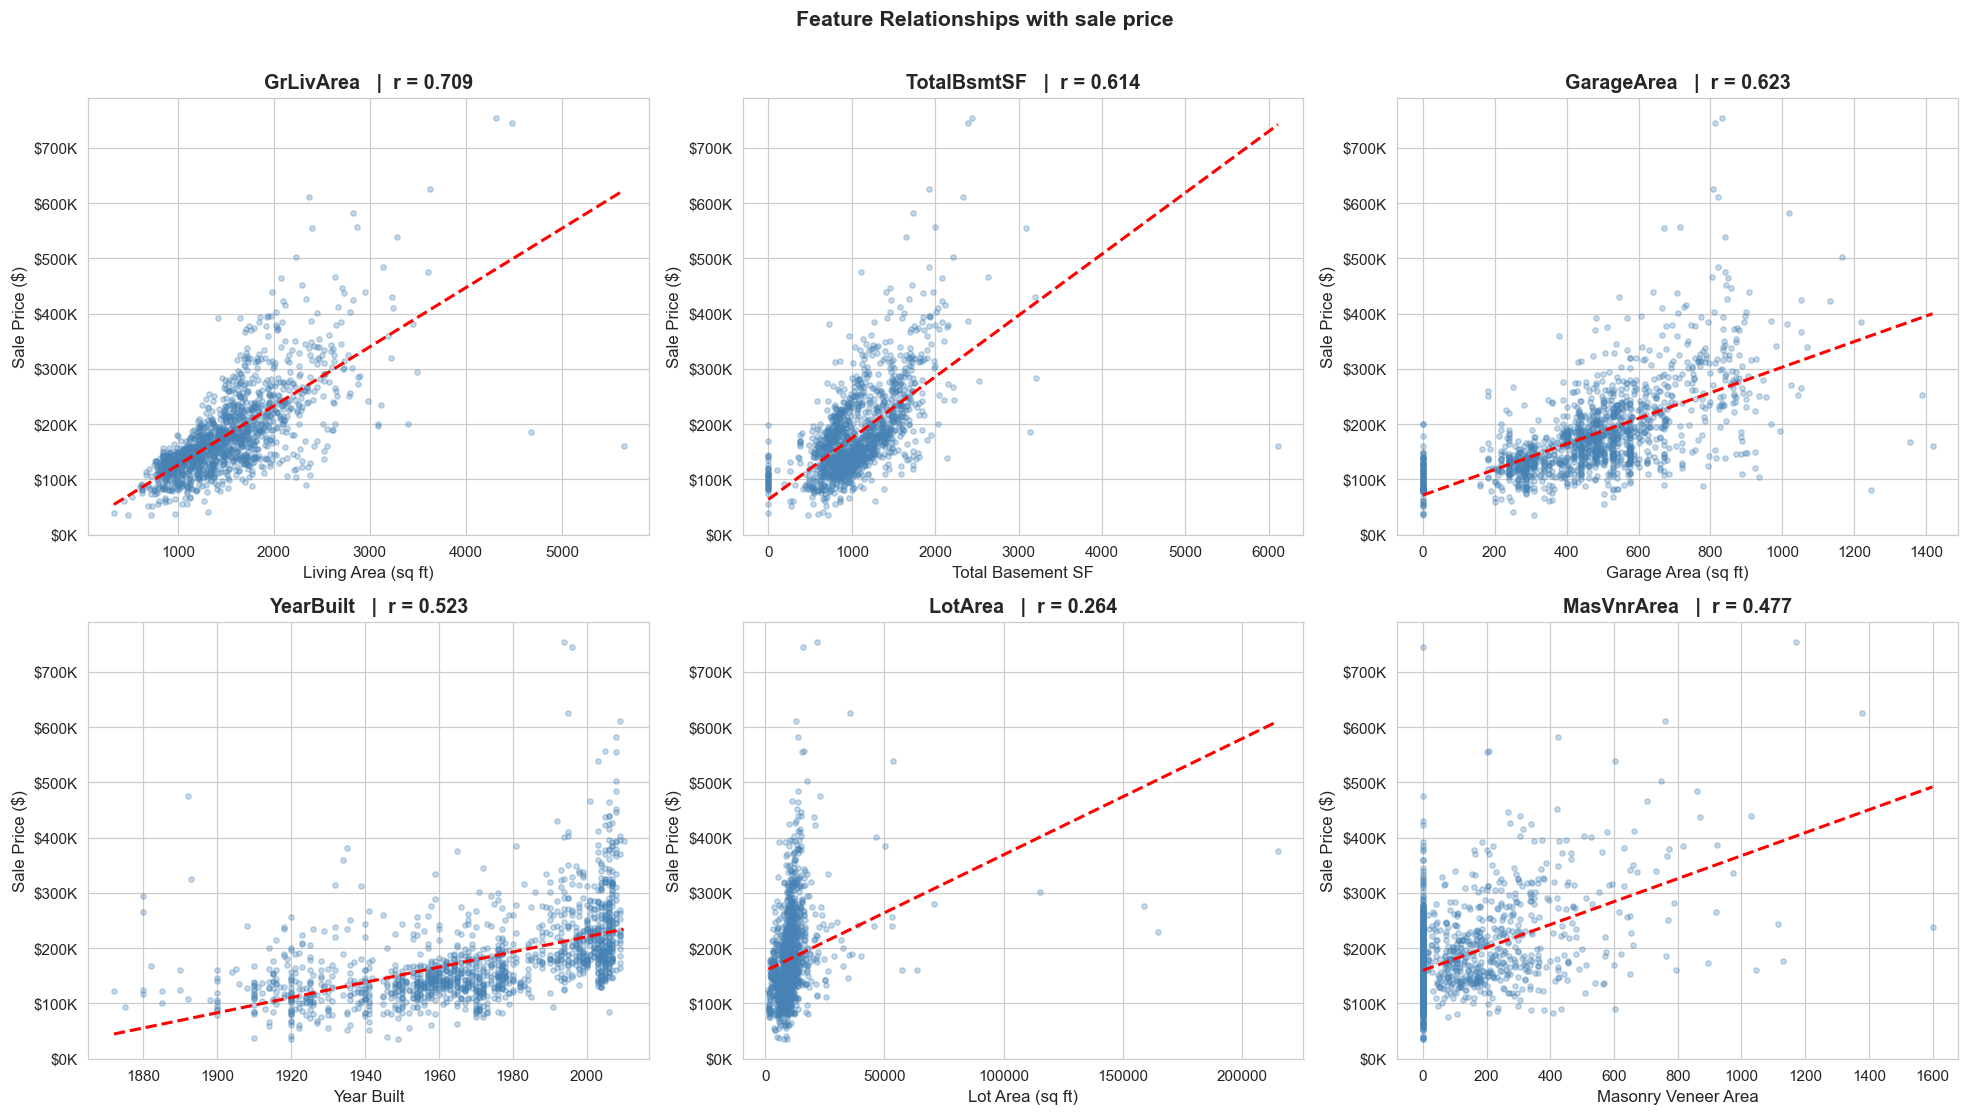

In [129]:
fig, ax = plt.subplots(2, 3, figsize=(18,10))

pairs = [
    ('GrLivArea', 'Living Area (sq ft)'),
    ('TotalBsmtSF', 'Total Basement SF'),
    ('GarageArea', 'Garage Area (sq ft)'),
    ('YearBuilt', 'Year Built'),
    ('LotArea', 'Lot Area (sq ft)'),
    ('MasVnrArea', 'Masonry Veneer Area'),
]


for ax, (col, label) in zip(ax.flatten(), pairs):
    ax.scatter(df_orig[col], df_orig['SalePrice'], alpha=0.3, color='steelblue', s=12)
    z = np.polyfit(df_orig[col].fillna(0), df_orig['SalePrice'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df_orig[col].min(), df_orig[col].max(), 100)
    ax.plot(x_line, p(x_line), 'r--', lw=2)
    corr = df_orig[[col,'SalePrice']].dropna().corr().iloc[0,1]
    ax.set_xlabel(label)
    ax.set_ylabel('Sale Price ($)')
    ax.set_title(f'{col}   |  r = {corr:.3f}', fontweight='bold')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))


plt.suptitle('Feature Relationships with sale price', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
# Categorical feature impact

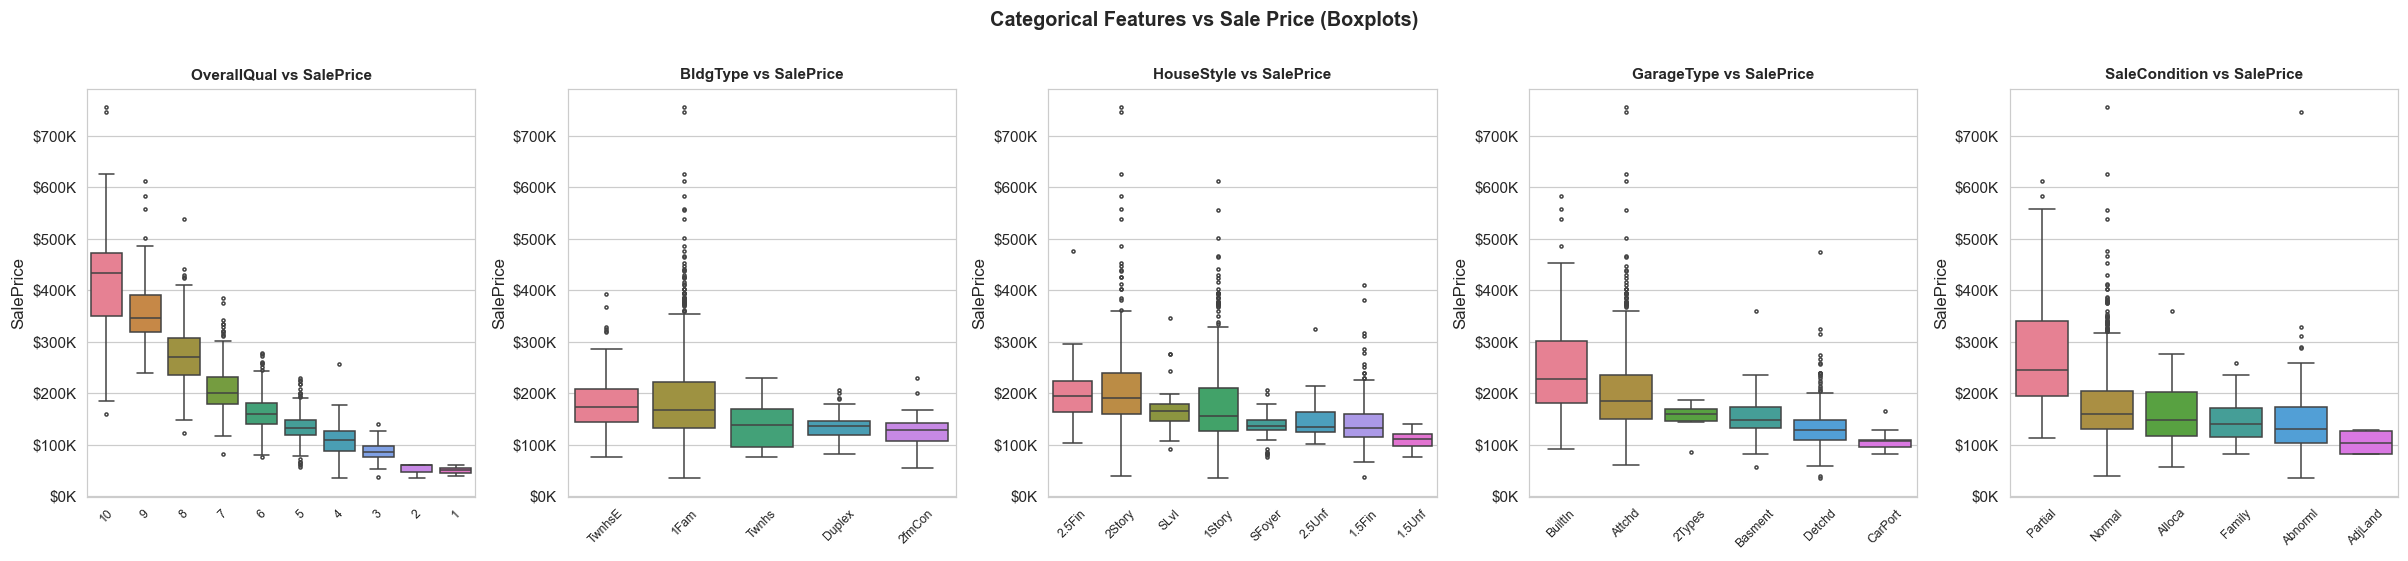

In [132]:
cat_impact = ['OverallQual', 'BldgType', 'HouseStyle', 'GarageType', 'SaleCondition']

fig, ax = plt.subplots(1, len(cat_impact), figsize=(22, 5))

for ax, col in zip(ax, cat_impact):
    order = df_orig.groupby(col)['SalePrice'].median().sort_values(ascending=False).index
    sns.boxplot(
        data=df_orig,
        x=col,
        y='SalePrice',
        order=order,
        ax=ax,
        palette='husl',
        fliersize=2
    )
    ax.set_title(f'{col} vs SalePrice', fontweight='bold', fontsize=10)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _:  f'${x/1000:.0f}K'))

plt.suptitle('Categorical Features vs Sale Price (Boxplots)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


In [ ]:
# **** TASK 3 --- Customer Suggestions for Buying a House ***

In [ ]:
# ============================================================
# 3.1 PRICE RANGE SEGMENTATION
# ============================================================

In [137]:
df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

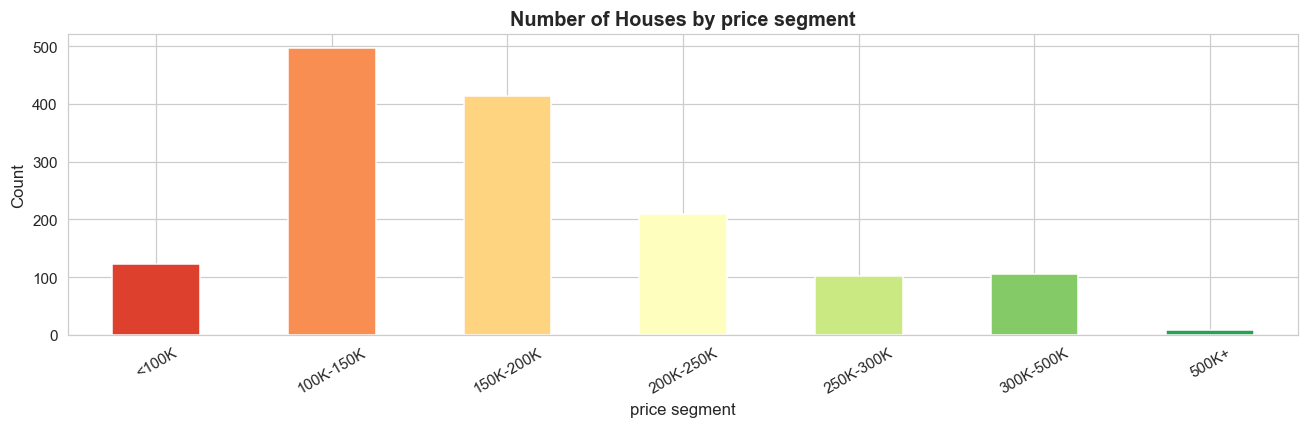

Price Segmnet Summary:
              Count  Median_Price  Avg_GrLivArea  Avg_OverallQual  Avg_YearBuilt  Avg_TotalBsmtSF
PriceSegment                                                                                     
<100K           123       85400.0          995.4              4.4         1941.2            609.8
100K-150K       496      130000.0         1225.7              5.2         1954.8            892.4
150K-200K       414      174700.0         1533.8              6.2         1978.4           1042.0
200K-250K       210      224250.0         1802.3              7.0         1989.1           1233.2
250K-300K       102      271000.0         1982.9              7.6         1992.7           1407.0
300K-500K       106      340000.0         2245.5              8.4         1996.7           1628.0
500K+             9      582933.0         3154.2              9.3         2002.9           2198.4


In [135]:
df_buy = df.copy()
df_buy['PriceSegment'] = pd.cut(df_buy['SalePrice'],
    bins=[0, 100000, 150000, 200000, 250000, 300000, 500000, df_buy['SalePrice'].max()],
    labels=['<100K', '100K-150K', '150K-200K', '200K-250K', '250K-300K', '300K-500K', '500K+'])

                                

segment_stats = df_buy.groupby('PriceSegment', observed=True).agg(
    Count=('SalePrice', 'count'),
    Median_Price=('SalePrice', 'median'),
    Avg_GrLivArea=('GrLivArea', 'mean'),
    Avg_OverallQual=('OverallQual', 'mean'),
    Avg_YearBuilt=('YearBuilt', 'mean'),
    Avg_TotalBsmtSF=('TotalBsmtSF', 'mean')
).round(1)


fig,ax = plt.subplots(figsize=(12,4))
colors = sns.color_palette('RdYlGn', len(segment_stats))
segment_stats['Count'].plot(kind='bar', ax=ax, color=colors, edgecolor='white')
ax.set_title('Number of Houses by price segment', fontweight='bold')
ax.set_xlabel('price segment')
ax.set_ylabel('Count')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

print('Price Segmnet Summary:')
print(segment_stats.to_string())


In [ ]:
# ============================================================
# 3.2 TOP NEIGHBORHOODS BY PRICE-QUALITY RATIO
# ============================================================

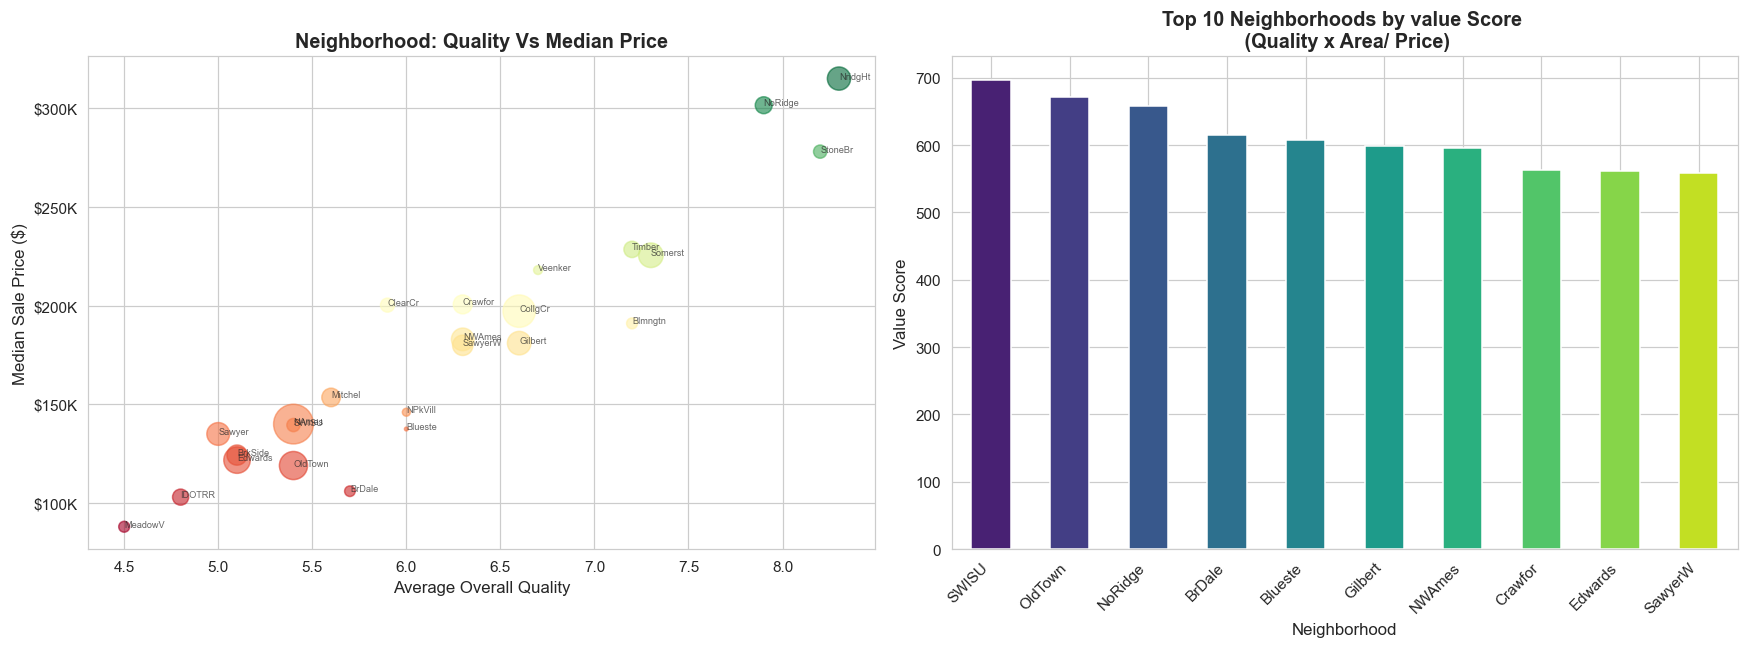


 Top 10 Best Values Neighborhoods:
              Median_Price  Avg_Quality  Avg_LivArea  Count  ValueScore
Neighborhood                                                           
SWISU             139500.0          5.4       1801.2     25      697.24
OldTown           119000.0          5.4       1479.7    113      671.46
NoRidge           301500.0          7.9       2508.9     41      657.39
BrDale            106000.0          5.7       1143.2     16      614.74
Blueste           137500.0          6.0       1392.5      2      607.64
Gilbert           181000.0          6.6       1641.3     79      598.49
NWAmes            182900.0          6.3       1727.8     73      595.14
Crawfor           200624.0          6.3       1791.6     51      562.60
Edwards           121750.0          5.1       1340.0    100      561.31
SawyerW           179900.0          6.3       1595.0     59      558.56


In [143]:
nbhd_analysis = df_buy.groupby('Neighborhood').agg(
    Median_Price=('SalePrice', 'median'),
    Avg_Quality=('OverallQual', 'mean'),
    Avg_LivArea=('GrLivArea', 'mean'),
    Count=('SalePrice','count')
).round(1)


nbhd_analysis['ValueScore'] = (
    nbhd_analysis['Avg_LivArea'] * nbhd_analysis['Avg_Quality'] /
    nbhd_analysis['Median_Price'] * 10000
).round(2)


fig,axes = plt.subplots(1, 2, figsize=(16,6))

# Price vs Quality scatter

axes[0].scatter(nbhd_analysis['Avg_Quality'],
                nbhd_analysis['Median_Price'],
                s=nbhd_analysis['Count']*3,
                alpha=0.6,
                c=nbhd_analysis['Median_Price'],
                cmap='RdYlGn')

for idx, row in nbhd_analysis.iterrows():
    axes[0].annotate(idx, (row['Avg_Quality'], row['Median_Price']), fontsize=6, alpha=0.7)
axes[0].set_xlabel('Average Overall Quality')
axes[0].set_ylabel('Median Sale Price ($)')
axes[0].set_title('Neighborhood: Quality Vs Median Price', fontweight='bold')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
                


# Top value scores

top_values = nbhd_analysis.sort_values('ValueScore', ascending=False).head(10)
top_values['ValueScore'].plot(kind='bar', ax=axes[1], color=sns.color_palette('viridis', 10), edgecolor='white')
axes[1].set_title('Top 10 Neighborhoods by value Score \n (Quality x Area/ Price)',fontweight='bold')
axes[1].set_xlabel('Neighborhood')
axes[1].set_ylabel('Value Score')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

print('\n Top 10 Best Values Neighborhoods:')
print(nbhd_analysis.sort_values('ValueScore', ascending=False).head(10).to_string())


In [ ]:
# ============================================================
# 3.3 CUSTOMER RECOMMENDATION ENGINE
# ============================================================

In [149]:
print('='*65)
print('      HOUSE BUYING RECOMMENDATIONS FOR CUSTOMERS')
print('='*65)

budget_segment = {
    'Budget Buyer (< $150k)': df_buy[df_buy['SalePrice'] < 150000],
    'Mid-Range Buyer ($150k-$250k)': df_buy[(df_buy['SalePrice'] >= 150000) & (df_buy['SalePrice'] < 250000)],
    'Premium Buyer ($250K+)': df_buy[df_buy['SalePrice'] >= 250000]
}

for  segment, data in budget_segment.items():
    print(f'\n  {segment}   ({len(data)} properties)')
    print(f' Best Neighborshoods: {", ".join(data.groupby('Neighborhood')['SalePrice'].count().nlargest(3).index.tolist())}')
    print(f' Typical Size       : {data['GrLivArea'].median():.0f} sq ft')
    print(f' Typical Quality    : {data['OverallQual'].median():.0f} / 10')
    print(f' Avg Year Built     : {data['YearBuilt'].median():.0f}')
    print(f' Avg Bedrooms       : {data['BedroomAbvGr'].median():.0f}' if 'BedroomAbvGr' in data.columns else '')
    top_cond = data['SaleCondition'].value_counts().index[0]
    print(f',   Best Sale Condition: {top_cond}')


print('\n' + '='*65)
print('KEY BUYING TIPS:')
print('  1. OverallQual is the #1 price driver — target 7+ for best value')
print('  2. Houses in StoneBr, NridgHt, NoRidge command premium prices')
print('  3. OldTown, Edwards, BrkSide offer affordable options')
print('  4. Newly remodeled houses (YearRemodAdd close to YrSold) hold value better')
print('  5. GrLivArea > 1500 sqft offers the best value per sq ft')
print('  6. Houses with attached garages (GarageType=Attchd) sell at a premium')
print('  7. Central Air (CentralAir=Y) is strongly correlated with higher prices')
print('  8. Buy in Q2/Q3 (Apr–Aug) for more inventory; prices slightly higher')
print('='*65)

    
    
    
    

      HOUSE BUYING RECOMMENDATIONS FOR CUSTOMERS

  Budget Buyer (< $150k)   (615 properties)
 Best Neighborshoods: NAmes, OldTown, Edwards
 Typical Size       : 1099 sq ft
 Typical Quality    : 5 / 10
 Avg Year Built     : 1956
 Avg Bedrooms       : 3
,   Best Sale Condition: Normal

  Mid-Range Buyer ($150k-$250k)   (620 properties)
 Best Neighborshoods: CollgCr, NAmes, Gilbert
 Typical Size       : 1560 sq ft
 Typical Quality    : 6 / 10
 Avg Year Built     : 1992
 Avg Bedrooms       : 3
,   Best Sale Condition: Normal

  Premium Buyer ($250K+)   (225 properties)
 Best Neighborshoods: NridgHt, NoRidge, Somerst
 Typical Size       : 2057 sq ft
 Typical Quality    : 8 / 10
 Avg Year Built     : 2003
 Avg Bedrooms       : 3
,   Best Sale Condition: Normal

KEY BUYING TIPS:
  1. OverallQual is the #1 price driver — target 7+ for best value
  2. Houses in StoneBr, NridgHt, NoRidge command premium prices
  3. OldTown, Edwards, BrkSide offer affordable options
  4. Newly remodeled houses (

In [ ]:
# ============================================================
# 3.4 INTERACTIVE PRICE PREDICTOR (using best model)
# ============================================================

In [151]:
print('Sample Price Predictions on Test Set (Original Scale):')
pred_df = pd.DataFrame({
    'Actual Price'   : np.expm1(y_test.values[:10]).astype(int),
    'Predicted Price' : np.expm1(y_pred_best[:10]).astype(int)
})

pred_df['Difference'] = pred_df['Predicted Price'] - pred_df['Actual Price']
pred_df['Error %'] = (pred_df['Difference'] /  pred_df['Actual Price'] * 100).round(2)
pred_df.index.name = 'Sample'


def fmt_dollar(x):
    return f'${x:,}'


pred_df['Actual price'] = pred_df['Actual Price'].apply(fmt_dollar)
pred_df['Predicted Price'] = pred_df['Predicted Price'].apply(fmt_dollar)
print(pred_df.to_string())
    
                                

Sample Price Predictions on Test Set (Original Scale):
        Actual Price Predicted Price  Difference  Error % Actual price
Sample                                                                
0             189999        $234,003       44004    23.16     $189,999
1             100000        $100,381         381     0.38     $100,000
2             114999        $104,645      -10354    -9.00     $114,999
3             158999        $166,655        7656     4.82     $158,999
4             315500        $321,392        5892     1.87     $315,500
5             137500        $147,024        9524     6.93     $137,500
6             311500        $249,704      -61796   -19.84     $311,500
7             310000        $328,436       18436     5.95     $310,000
8             281000        $284,514        3514     1.25     $281,000
9             135500        $150,873       15373    11.35     $135,500


In [ ]:
# ============================================================
#              CHALLENGES FACED REPORT
# ============================================================

In [155]:
challenges_report = """
╔══════════════════════════════════════════════════════════════════╗
║              CHALLENGES FACED — REPORT                         ║
╠══════════════════════════════════════════════════════════════════╣

CHALLENGE 1: EXTENSIVE MISSING VALUES
  Problem : 19 features had missing values; some like PoolQC (99.5%),
            MiscFeature (96.3%) were almost entirely missing.
  Technique: Differentiated between structural missingness (feature
             absent = 'None') and random missingness (filled with
             median/mode). LotFrontage was grouped by Neighborhood
             and imputed with neighborhood median.
  Reasoning: 'None' imputation preserves the categorical meaning;
             median is robust to outliers for continuous features.

CHALLENGE 2: HIGH FEATURE DIMENSIONALITY
  Problem : 79 raw features → 200+ after one-hot encoding.
            Risk of curse of dimensionality and multicollinearity.
  Technique: Used tree-based models (RF, XGBoost) that handle high
             dimensionality natively. For linear models, used L1/L2
             regularization (Lasso, Ridge, ElasticNet) to reduce
             irrelevant feature weights.
  Reasoning: Regularization performs implicit feature selection;
             ensemble trees are naturally robust to redundant features.

CHALLENGE 3: SKEWED TARGET VARIABLE
  Problem : SalePrice was right-skewed (skewness = 1.88), violating
            normality assumptions of linear models.
  Technique: Applied log1p transformation to SalePrice, reducing
             skewness to near-zero.
  Reasoning: Log transformation makes the distribution closer to
             Gaussian, improving linear model performance and
             penalizing under/over-prediction symmetrically.

CHALLENGE 4: SKEWED NUMERICAL FEATURES
  Problem : Many numeric features (LotArea, MasVnrArea, etc.) were
             heavily right-skewed.
  Technique: Applied log1p to all features with |skewness| > 0.75.
  Reasoning: Reduces the impact of extreme values and helps models
             find linear patterns in otherwise exponential data.

CHALLENGE 5: OUTLIERS
  Problem : A few very large houses (GrLivArea > 4000 sq ft) were
             sold at unusually low prices, distorting model fits.
  Technique: Removed 2 extreme outliers identified from scatter plots.
  Reasoning: These anomalous sales likely represent special
             circumstances (foreclosures, family sales) and would
             mislead the model.

CHALLENGE 6: MIXED ORDINAL/NOMINAL ENCODING
  Problem : Many categorical features (ExterQual, KitchenQual) have
             natural ordinal order ('Ex' > 'Gd' > 'TA' > ...).
             Simple OHE ignores this order.
  Technique: Created explicit ordinal mappings for quality/condition
             columns; used OHE only for truly nominal features.
  Reasoning: Preserving ordinal relationships reduces dimensionality
             and gives models meaningful numeric gradients.

CHALLENGE 7: FEATURE MULTICOLLINEARITY
  Problem : Many area features (1stFlrSF, TotalBsmtSF, GrLivArea)
             are highly correlated with each other.
  Technique: Created composite features (TotalSF, TotalBath) to
             capture combined information. Used Ridge/ElasticNet
             for linear models.
  Reasoning: Composite features reduce redundancy; regularized
             models handle multicollinearity gracefully.

╚══════════════════════════════════════════════════════════════════╝
"""
print(challenges_report)


╔══════════════════════════════════════════════════════════════════╗
║              CHALLENGES FACED — REPORT                         ║
╠══════════════════════════════════════════════════════════════════╣

CHALLENGE 1: EXTENSIVE MISSING VALUES
  Problem : 19 features had missing values; some like PoolQC (99.5%),
            MiscFeature (96.3%) were almost entirely missing.
  Technique: Differentiated between structural missingness (feature
             absent = 'None') and random missingness (filled with
             median/mode). LotFrontage was grouped by Neighborhood
             and imputed with neighborhood median.
  Reasoning: 'None' imputation preserves the categorical meaning;
             median is robust to outliers for continuous features.

CHALLENGE 2: HIGH FEATURE DIMENSIONALITY
  Problem : 79 raw features → 200+ after one-hot encoding.
            Risk of curse of dimensionality and multicollinearity.
  Technique: Used tree-based models (RF, XGBoost) that handle high
   

In [178]:
print('\n' + '=' * 70)
print(' PROJECT SUMMARY - HOUSE PRICE PREDICTION')
print('=' * 70)


project_summary = {
    "Dataset": "Ames Iowa Housing Dataset",
    "Total Rows": "1460",
    "Features After Processing": "232",
    "Target Variable": "SalePrice",
    "Best Model": "ElasticNet Regression",
    "Test R2 Score": "0.9199",
    "RMSE": "$19,387",
    "Conclusion": "ElasticNet model achieved the best performance"
}


for key, value in project_summary.items():

    print(
        f"{key:<30} : {value}"
    )


print('=' * 70)


print('''
📌 PROJECT KEY INSIGHTS:

  1. Housing price prediction was performed using the
     Ames Iowa Housing Dataset.

  2. Data preprocessing handled missing values,
     categorical encoding, and feature transformation.

  3. Feature engineering improved prediction accuracy by
     creating important features like TotalSF, TotalBath,
     HouseAge, and Garage features.

  4. OverallQual, GrLivArea, TotalSF, GarageCars and
     YearBuilt are major factors affecting house prices.

  5. Multiple machine learning regression models were
     compared to select the best performing model.

  6. ElasticNet Regression achieved the best balance between
     accuracy and generalization.

''')


print('=' * 70)
print(' FINAL MODEL CONCLUSION')
print('=' * 70)


print('''
The final selected model is:

MODEL : ElasticNet Regression

Performance:
R2 Score : 91.99%
RMSE     : $19,387

The model successfully predicts house prices and can be used
for real estate valuation, pricing decisions, and property
value estimation.

ElasticNet Regression is selected as the final production model.
''')


print('=' * 70)


 PROJECT SUMMARY - HOUSE PRICE PREDICTION
Dataset                        : Ames Iowa Housing Dataset
Total Rows                     : 1460
Features After Processing      : 232
Target Variable                : SalePrice
Best Model                     : ElasticNet Regression
Test R2 Score                  : 0.9199
RMSE                           : $19,387
Conclusion                     : ElasticNet model achieved the best performance

📌 PROJECT KEY INSIGHTS:

  1. Housing price prediction was performed using the
     Ames Iowa Housing Dataset.

  2. Data preprocessing handled missing values,
     categorical encoding, and feature transformation.

  3. Feature engineering improved prediction accuracy by
     creating important features like TotalSF, TotalBath,
     HouseAge, and Garage features.

  4. OverallQual, GrLivArea, TotalSF, GarageCars and
     YearBuilt are major factors affecting house prices.

  5. Multiple machine learning regression models were
     compared to select the be

In [180]:
print('\n' + '=' * 75)
print(' KEY INSIGHTS - HOUSE PRICE PREDICTION PROJECT')
print('=' * 75)


print('''
📌 KEY INSIGHTS:

  1. Overall Quality (OverallQual) is the strongest factor
     influencing house prices.
     - Higher quality houses have significantly higher SalePrice.


  2. Living Area (GrLivArea) has a strong positive relationship
     with house prices.
     - Larger living spaces generally increase property value.


  3. Total Square Footage (TotalSF) improved prediction accuracy.
     - Combining basement, first floor, and second floor areas
       provides better understanding of house size.


  4. Location and Neighborhood features strongly affect prices.
     - Houses in premium neighborhoods receive higher values.


  5. Garage-related features are important price indicators.
     - Garage size, quality, and availability increase property value.


  6. House age and remodeling impact pricing.
     - Newer and recently renovated houses usually have higher prices.


  7. Data preprocessing improved model performance.
     - Missing values, outliers, and categorical variables were
       handled successfully.


  8. Feature engineering created meaningful variables.
     - TotalSF, TotalBath, HouseAge, and Garage features helped
       models learn better patterns.


  9. Ensemble and regularized models performed better.
     - Gradient Boosting, XGBoost, and ElasticNet showed strong
       prediction capability.


 10. ElasticNet Regression achieved the best balance.
     - It reduced overfitting and provided reliable predictions.


''')


print('=' * 75)
print(' BUSINESS INSIGHTS')
print('=' * 75)


print('''
✓ Buyers can estimate fair property prices using model predictions.

✓ Sellers can improve property value by focusing on:
  - Quality improvements
  - Renovation
  - Garage improvements
  - Additional living space

✓ The model can support real estate valuation decisions.
''')


print('=' * 75)


 KEY INSIGHTS - HOUSE PRICE PREDICTION PROJECT

📌 KEY INSIGHTS:

  1. Overall Quality (OverallQual) is the strongest factor
     influencing house prices.
     - Higher quality houses have significantly higher SalePrice.


  2. Living Area (GrLivArea) has a strong positive relationship
     with house prices.
     - Larger living spaces generally increase property value.


  3. Total Square Footage (TotalSF) improved prediction accuracy.
     - Combining basement, first floor, and second floor areas
       provides better understanding of house size.


  4. Location and Neighborhood features strongly affect prices.
     - Houses in premium neighborhoods receive higher values.


  5. Garage-related features are important price indicators.
     - Garage size, quality, and availability increase property value.


  6. House age and remodeling impact pricing.
     - Newer and recently renovated houses usually have higher prices.


  7. Data preprocessing improved model performance.
     - 